使用AutoTS自动训练时间序列模型，测试数据集质量。

In [1]:
#读取数据
import pandas as pd
BaseData=pd.read_csv('/root/AnalysisData/AnalysisData.csv',parse_dates=["Date"])
BaseData.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         60 non-null     int64         
 1   Date               60 non-null     datetime64[us]
 2   Pressure(hPa)      60 non-null     float64       
 3   RH(%)              60 non-null     float64       
 4   WindSpeed(m/s)     60 non-null     float64       
 5   temperature_mean   60 non-null     float64       
 6   temperature_min    60 non-null     float64       
 7   temperature_max    60 non-null     float64       
 8   petPM(mm)          60 non-null     float64       
 9   precipitation(mm)  60 non-null     float64       
 10  IR                 60 non-null     float64       
dtypes: datetime64[us](1), float64(9), int64(1)
memory usage: 5.3 KB


In [2]:
#统计空缺数据
BaseData.isnull().sum()

Unnamed: 0           0
Date                 0
Pressure(hPa)        0
RH(%)                0
WindSpeed(m/s)       0
temperature_mean     0
temperature_min      0
temperature_max      0
petPM(mm)            0
precipitation(mm)    0
IR                   0
dtype: int64

In [3]:
#移除多余列数据
BaseData.drop(labels=['Unnamed: 0'],inplace=True,axis=1)

In [4]:
#分离气象因素和HFMD发病率数据
Climate=BaseData.iloc[:,1:-1]
Climate.index=BaseData['Date']
HFMDIR=BaseData.loc[:,'IR']
HFMDIR.index=BaseData['Date']

In [5]:
#构建滞后1阶气象变量
Climate['precipitation(mm)_Log1']=Climate.loc[:,'precipitation(mm)'].shift(1)
Climate.fillna(0,inplace=True)
Climate.isnull().sum()

Pressure(hPa)             0
RH(%)                     0
WindSpeed(m/s)            0
temperature_mean          0
temperature_min           0
temperature_max           0
petPM(mm)                 0
precipitation(mm)         0
precipitation(mm)_Log1    0
dtype: int64

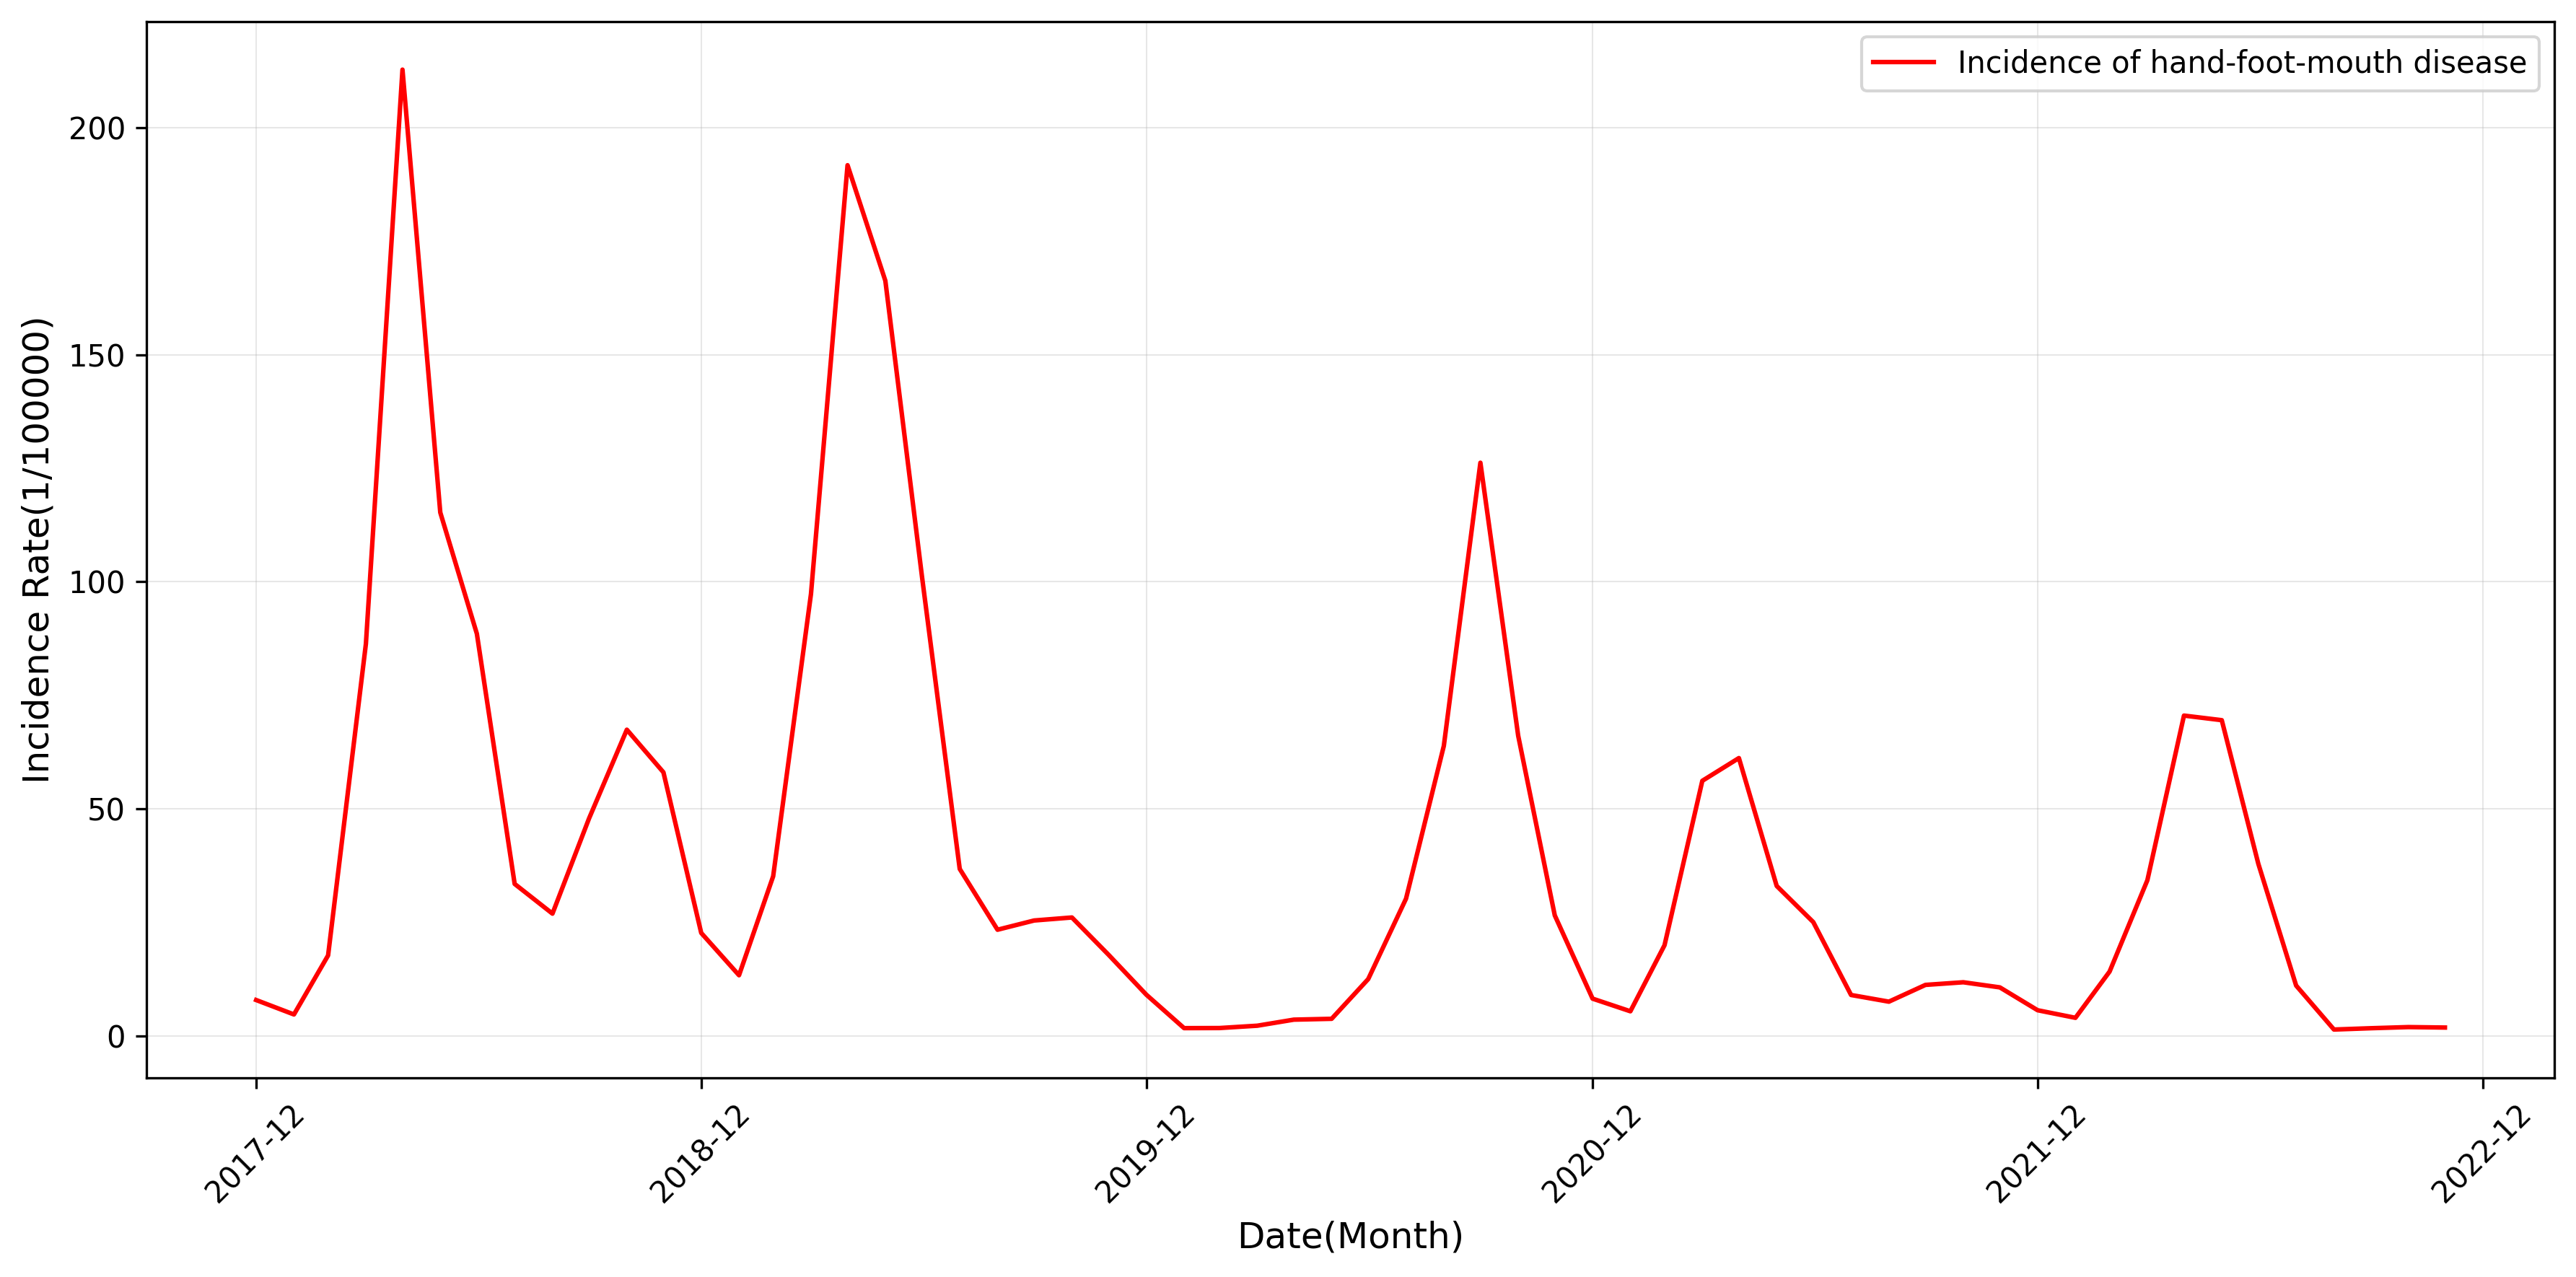

In [6]:
#绘制疾病数据曲线图
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.dates import DateFormatter, AutoDateLocator
fig,ax=plt.subplots(figsize=(12, 6),dpi=300)
ax.plot(HFMDIR.index, HFMDIR, label='Incidence of hand-foot-mouth disease', color='red',linestyle='-')
date_locator = AutoDateLocator()
date_formatter = DateFormatter("%Y-%m")
ax.xaxis.set_major_locator(date_locator)
ax.xaxis.set_major_formatter(date_formatter)
plt.xticks(rotation=45)
ax.set_title('')
ax.set_xlabel("Date(Month)", fontsize=12)
ax.set_ylabel("Incidence Rate(1/100000)", fontsize=12)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.show()

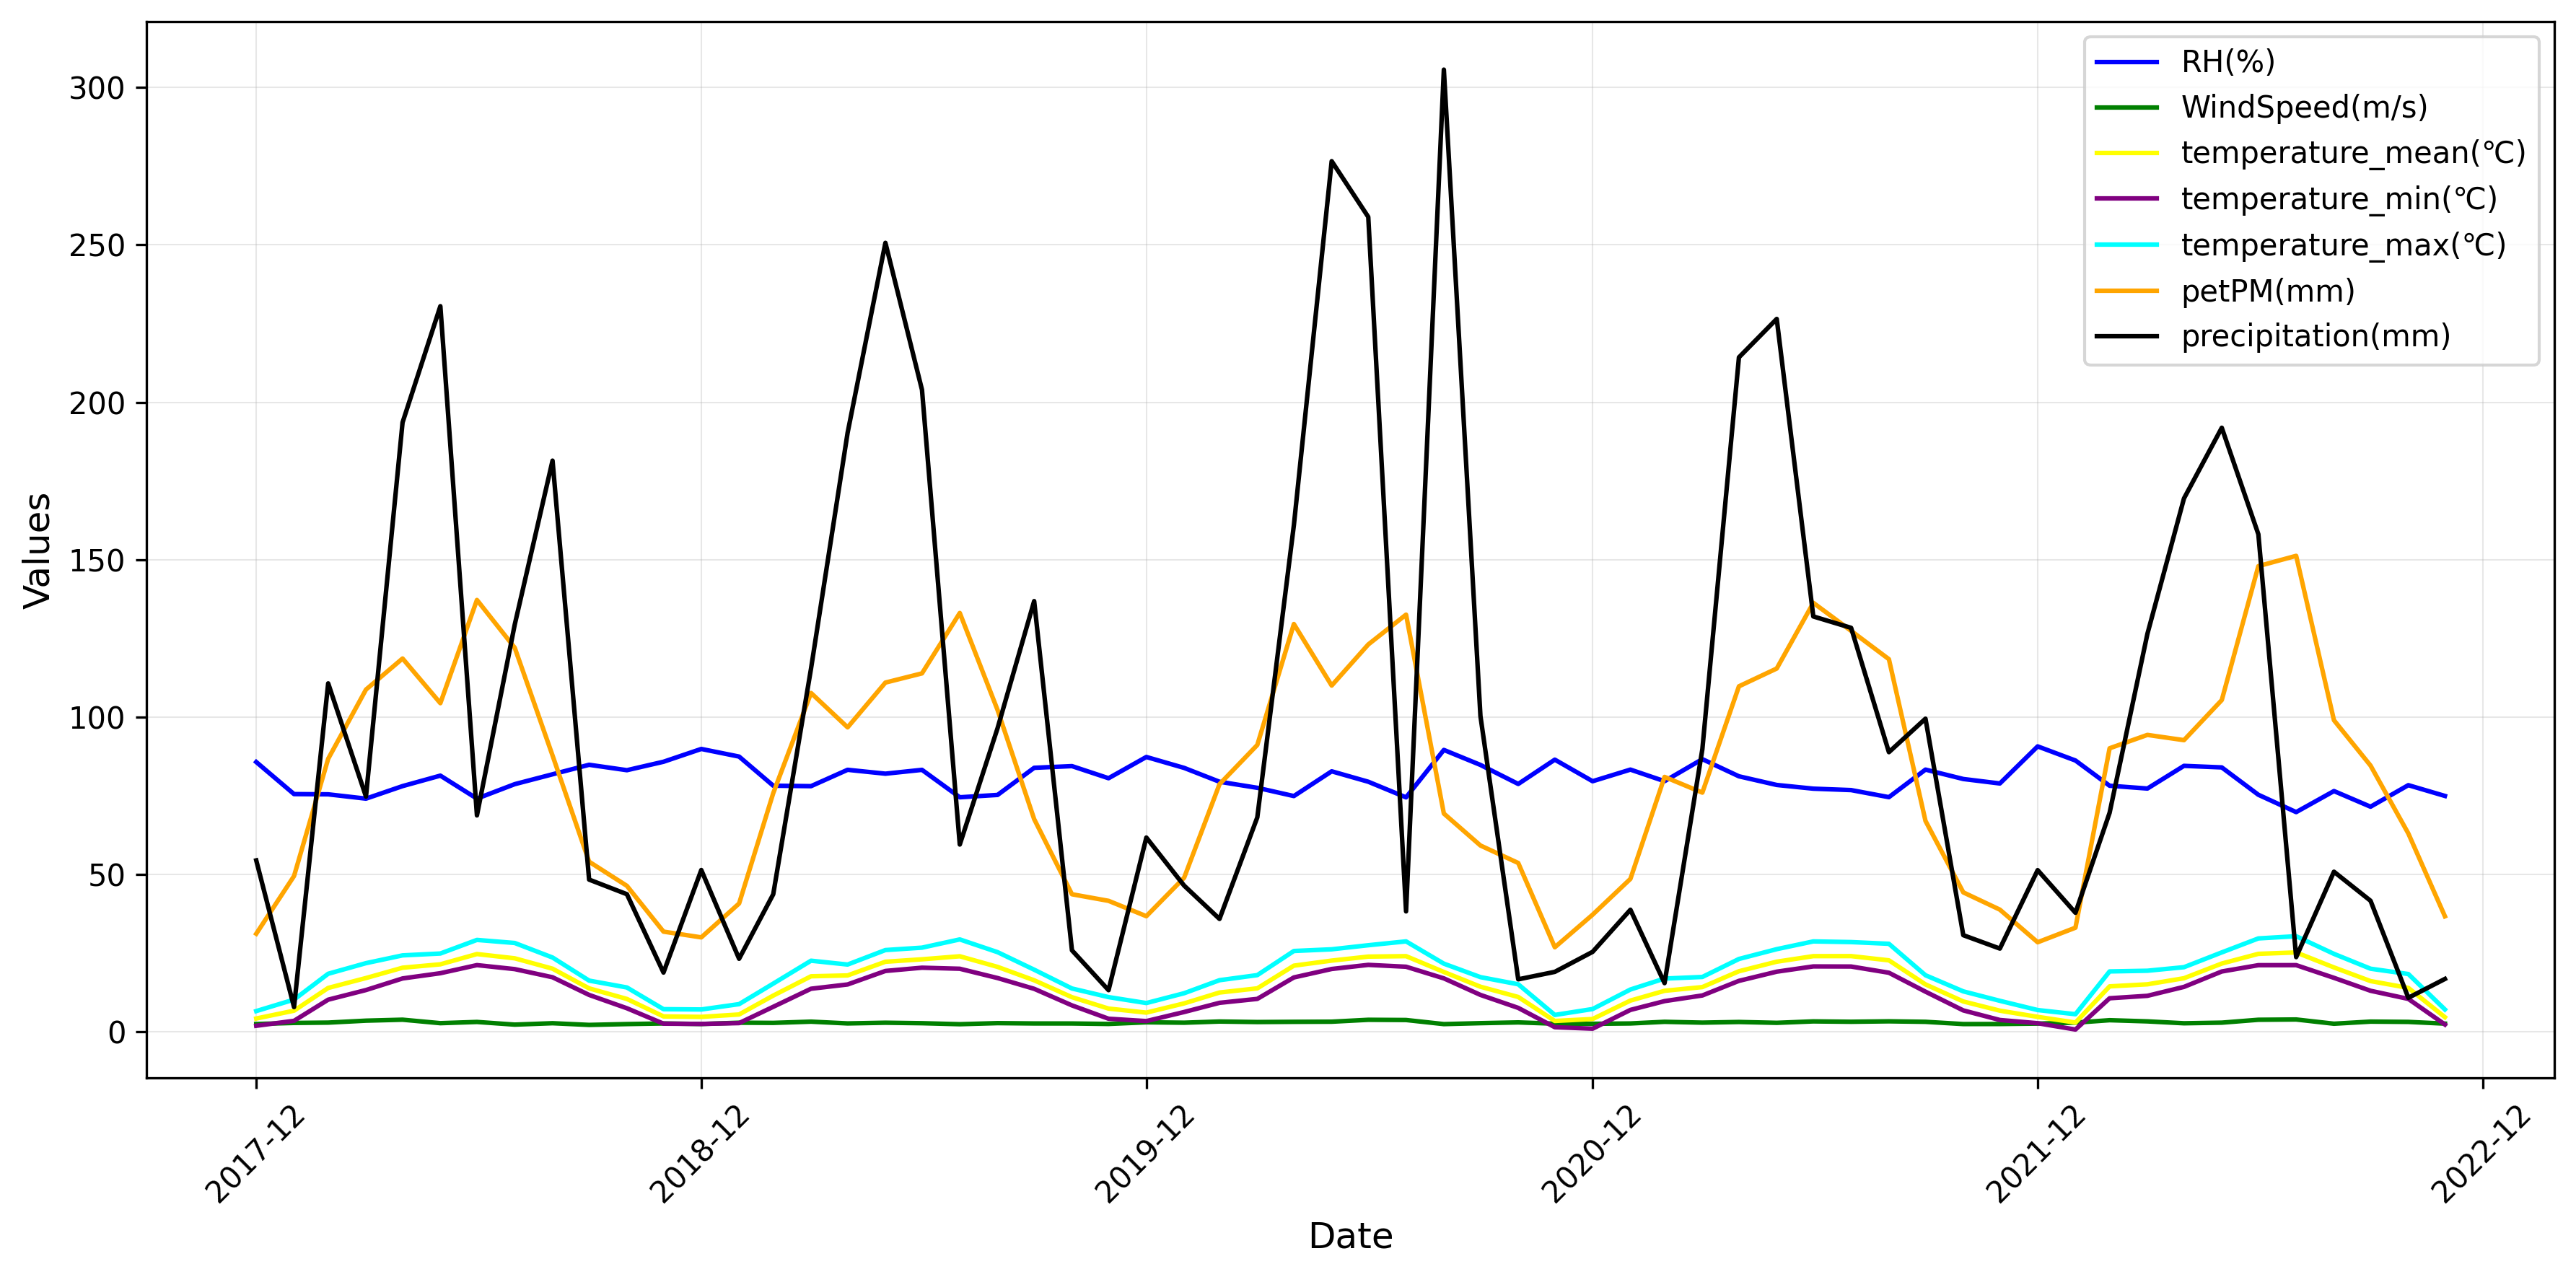

In [7]:
fig,ax=plt.subplots(figsize=(12, 6),dpi=300)
ax.plot(Climate.index,Climate['RH(%)'], label='RH(%)', color='blue',linestyle='-')
ax.plot(Climate.index,Climate['WindSpeed(m/s)'], label='WindSpeed(m/s)', color='green',linestyle='-')
ax.plot(Climate.index,Climate['temperature_mean'], label='temperature_mean(℃)', color='yellow',linestyle='-')
ax.plot(Climate.index,Climate['temperature_min'], label='temperature_min(℃)', color='purple',linestyle='-')
ax.plot(Climate.index,Climate['temperature_max'], label='temperature_max(℃)', color='cyan',linestyle='-')
ax.plot(Climate.index,Climate['petPM(mm)'], label='petPM(mm)', color='orange',linestyle='-')
ax.plot(Climate.index,Climate['precipitation(mm)'], label='precipitation(mm)', color='black',linestyle='-')
#ax.plot(Climate.index,Climate['precipitation(mm)_Log1'], label='precipitation(mm)_Log1', color='brown',linestyle='-')
date_locator = AutoDateLocator()
date_formatter = DateFormatter("%Y-%m")
ax.xaxis.set_major_locator(date_locator)
ax.xaxis.set_major_formatter(date_formatter)
plt.xticks(rotation=45)
ax.set_title('')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Values", fontsize=12)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.show()

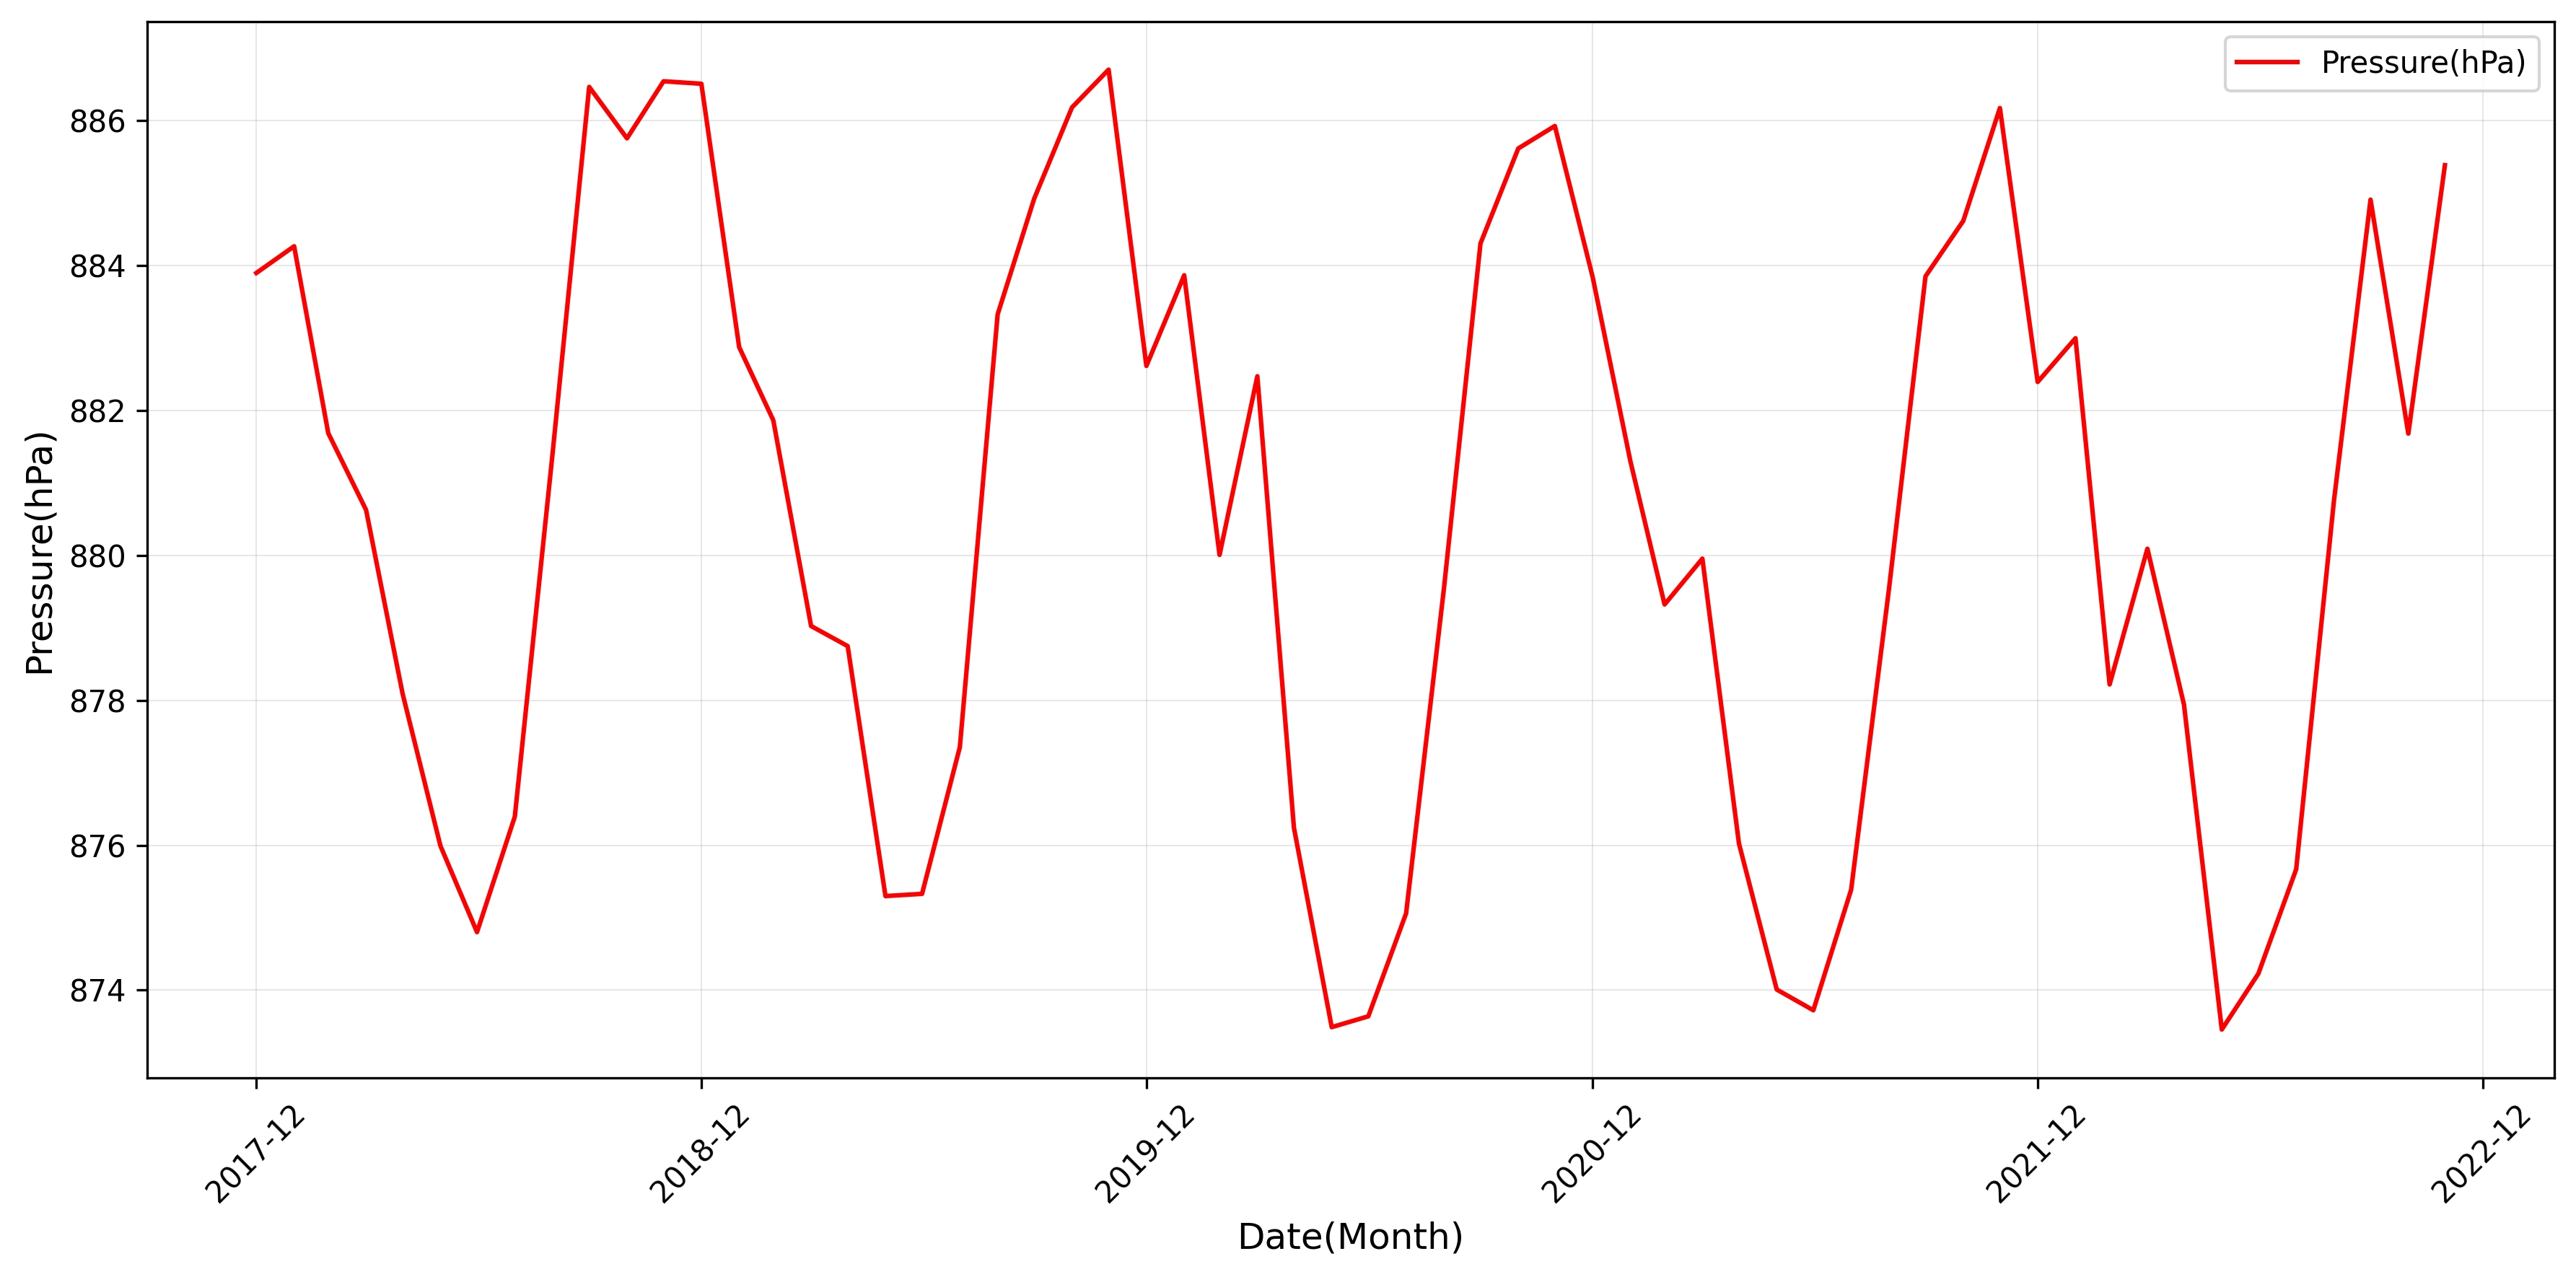

In [8]:
fig,ax=plt.subplots(figsize=(12, 6),dpi=300)
ax.plot(Climate.index,Climate['Pressure(hPa)'], label='Pressure(hPa)', color='red',linestyle='-')
date_locator = AutoDateLocator()
date_formatter = DateFormatter("%Y-%m")
ax.xaxis.set_major_locator(date_locator)
ax.xaxis.set_major_formatter(date_formatter)
plt.xticks(rotation=45)
ax.set_title('')
ax.set_xlabel("Date(Month)", fontsize=12)
ax.set_ylabel("Pressure(hPa)", fontsize=12)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.show()

数据分布特征分析

In [9]:
#查看气象数据数据分布范围
Climate.describe()

,Pressure(hPa),RH(%),WindSpeed(m/s),temperature_mean,temperature_min,temperature_max,petPM(mm),precipitation(mm),precipitation(mm)_Log1
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,880.535974,80.350368,2.824808,15.058694,12.032207,18.774380,82.067250,97.031932,96.753789
std,4.189941,4.760036,0.416558,6.923105,6.677964,7.541338,36.116493,78.680248,78.997941
min,873.457640,69.717910,2.079886,2.822548,0.610893,5.248330,26.756428,7.756625,0.000000
25%,876.356000,77.057592,2.525405,9.740547,6.807149,13.184366,47.939460,37.229532,37.229532
50%,881.023500,79.540810,2.775848,14.971596,12.131782,19.191435,85.589175,68.359165,68.359165
75%,883.985500,83.829425,3.069913,21.401817,18.549950,25.295718,110.178642,142.098642,142.098642
max,886.698400,90.609890,3.805413,25.116170,21.163338,30.274044,151.175690,305.712000,305.712000


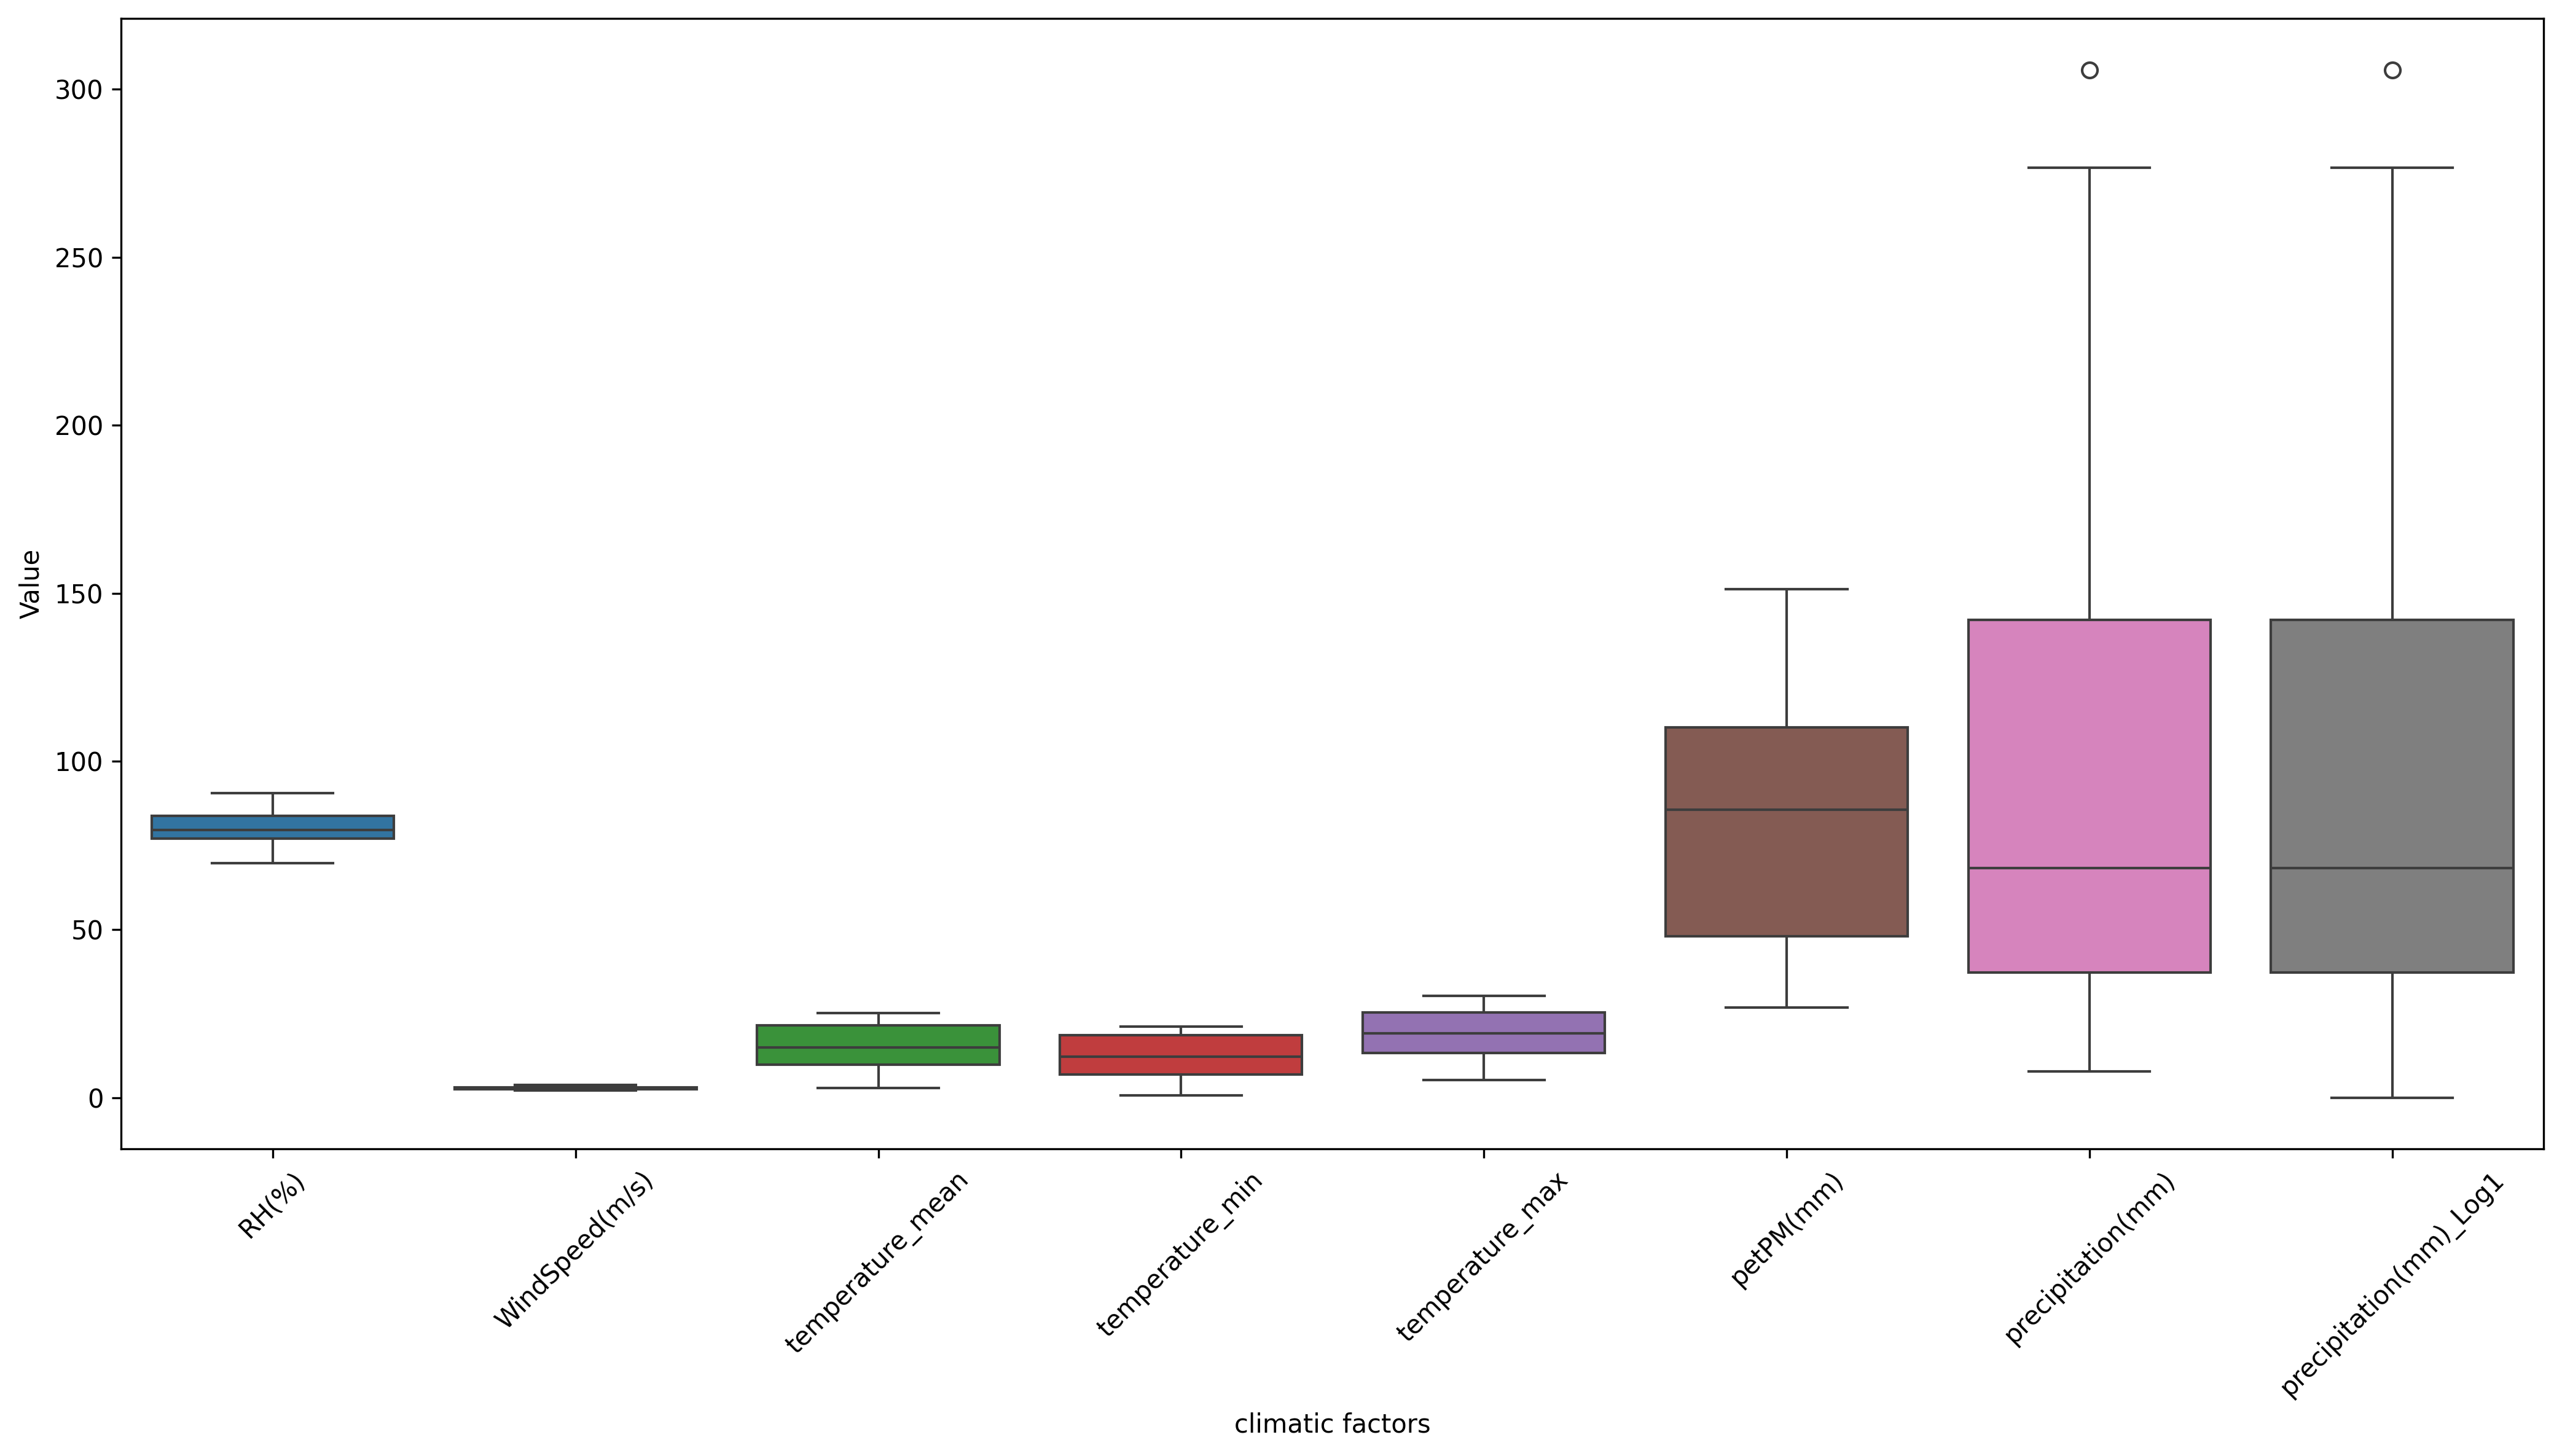

In [12]:
#绘制箱型图
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14,8),dpi=300)
sns.boxplot(data=Climate.iloc[:,1:])
plt.xlabel('climatic factors')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

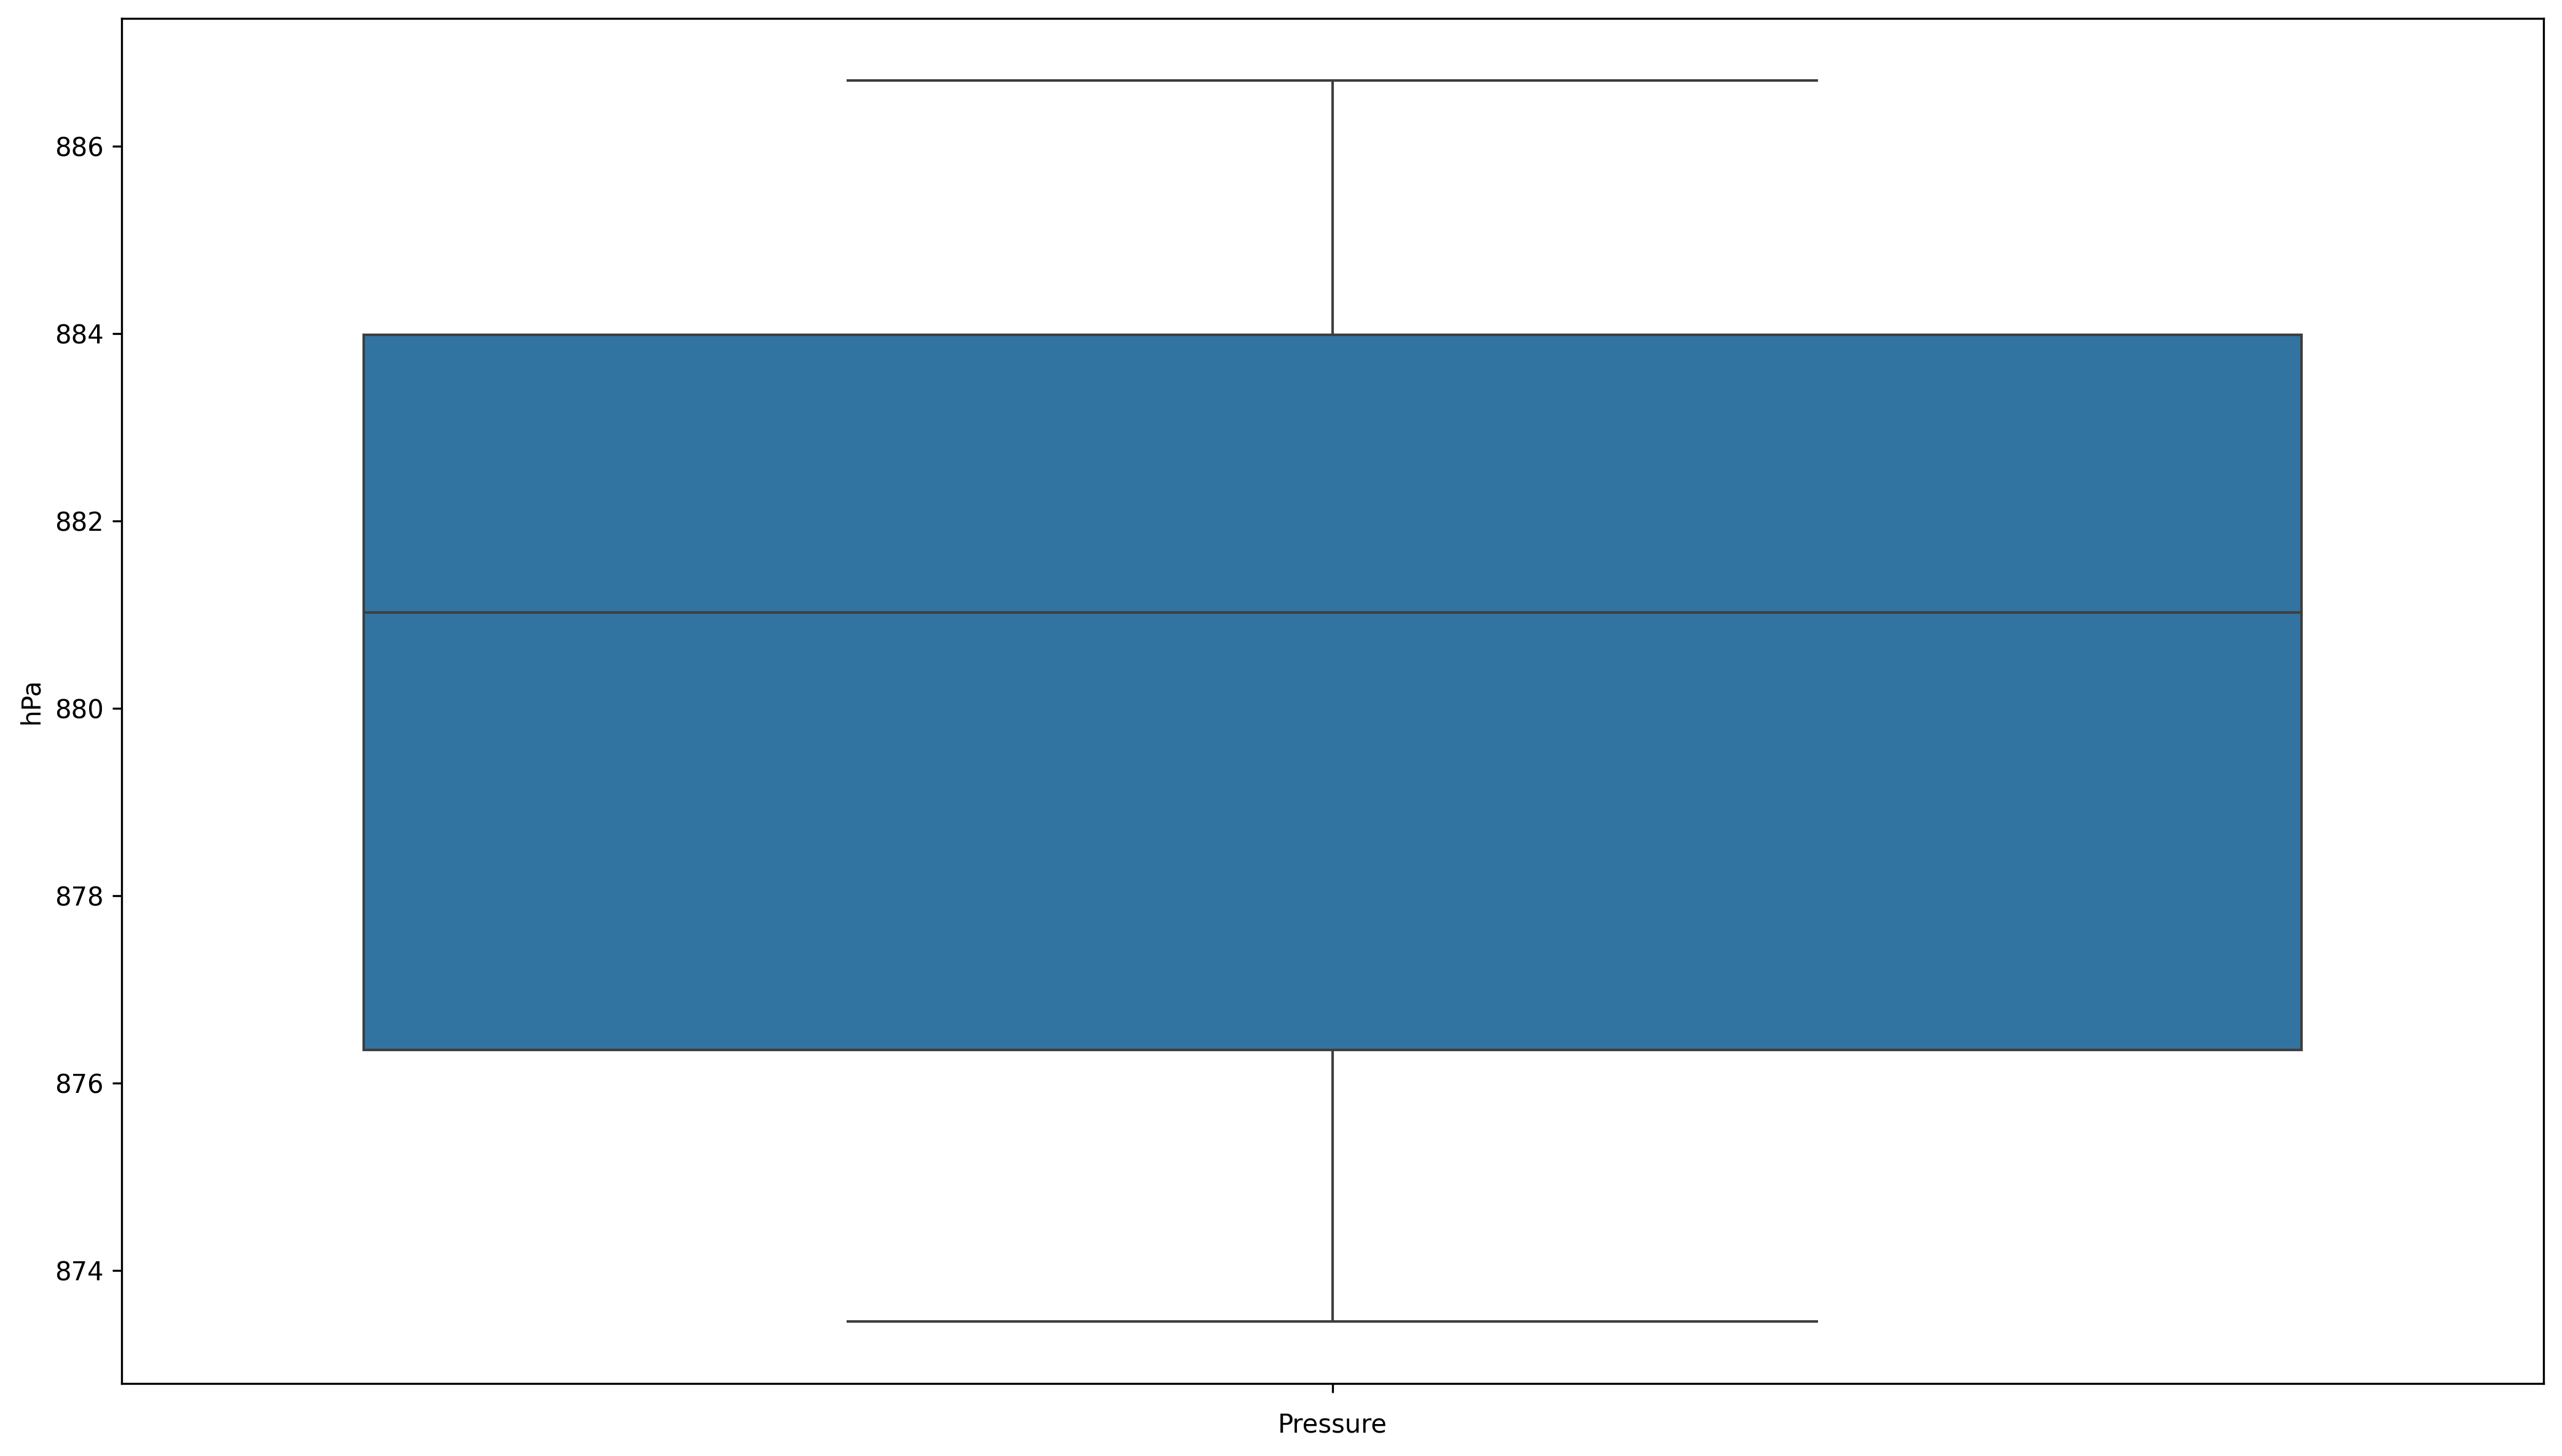

In [14]:
plt.figure(figsize=(14,8),dpi=300)
sns.boxplot(data=Climate.iloc[:,0])
plt.xlabel('Pressure')
plt.ylabel('hPa')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
#划分数据集
Climate_Train=Climate.iloc[:48,:]
Climate_Test=Climate.iloc[48:,:]
HFMDIR_Train=HFMDIR[:48]
HFMDIR_Test=HFMDIR[48:]

In [16]:
#由箱型图可知，各气象因素分布相差较大。使用归一化消除不同尺度带来的影响。
from sklearn.preprocessing import StandardScaler,MinMaxScaler
Stanard=StandardScaler()
Stanard_fit=Stanard.fit(Climate_Train)
Climate_Train_Sd=Stanard_fit.transform(Climate_Train)    #转化训练集
Climate_Test_Sd=Stanard_fit.transform(Climate_Test)    #转化测试集

In [17]:
#缩放至0-1范围内
MinMax=MinMaxScaler(feature_range=(0,1))
MinMax_fit=MinMax.fit(Climate_Train_Sd)
Climate_Train_Sd_Minmax=MinMax_fit.transform(Climate_Train_Sd)    #缩放训练集
Climate_Test_Sd_Minmax=MinMax_fit.transform(Climate_Test_Sd)    #缩放测试集 

In [18]:
#转化为DataFrame并添加行和列索引
from pandas import DataFrame
TrainClimate=DataFrame(Climate_Train_Sd_Minmax)    #训练集
TrainClimate.columns=Climate.columns
TrainClimate.index=Climate_Train.index
TestClimate=DataFrame(Climate_Test_Sd_Minmax)    #测试集
TestClimate.columns=Climate.columns
TestClimate.index=Climate_Test.index

In [19]:
#训练集-气象数据
TrainClimate.describe()

,Pressure(hPa),RH(%),WindSpeed(m/s),temperature_mean,temperature_min,temperature_max,petPM(mm),precipitation(mm),precipitation(mm)_Log1
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,0.547199,0.425628,0.421445,0.552083,0.551234,0.562909,0.493328,0.314788,0.330379
std,0.322904,0.273782,0.234824,0.320837,0.326936,0.307921,0.320753,0.274568,0.269569
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.216953,0.242912,0.263706,0.301173,0.292203,0.330587,0.191881,0.100047,0.122881
50%,0.595091,0.403020,0.394053,0.529184,0.554721,0.536230,0.480002,0.214473,0.234404
75%,0.816270,0.618979,0.592041,0.856154,0.871153,0.849873,0.768715,0.453321,0.467192
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


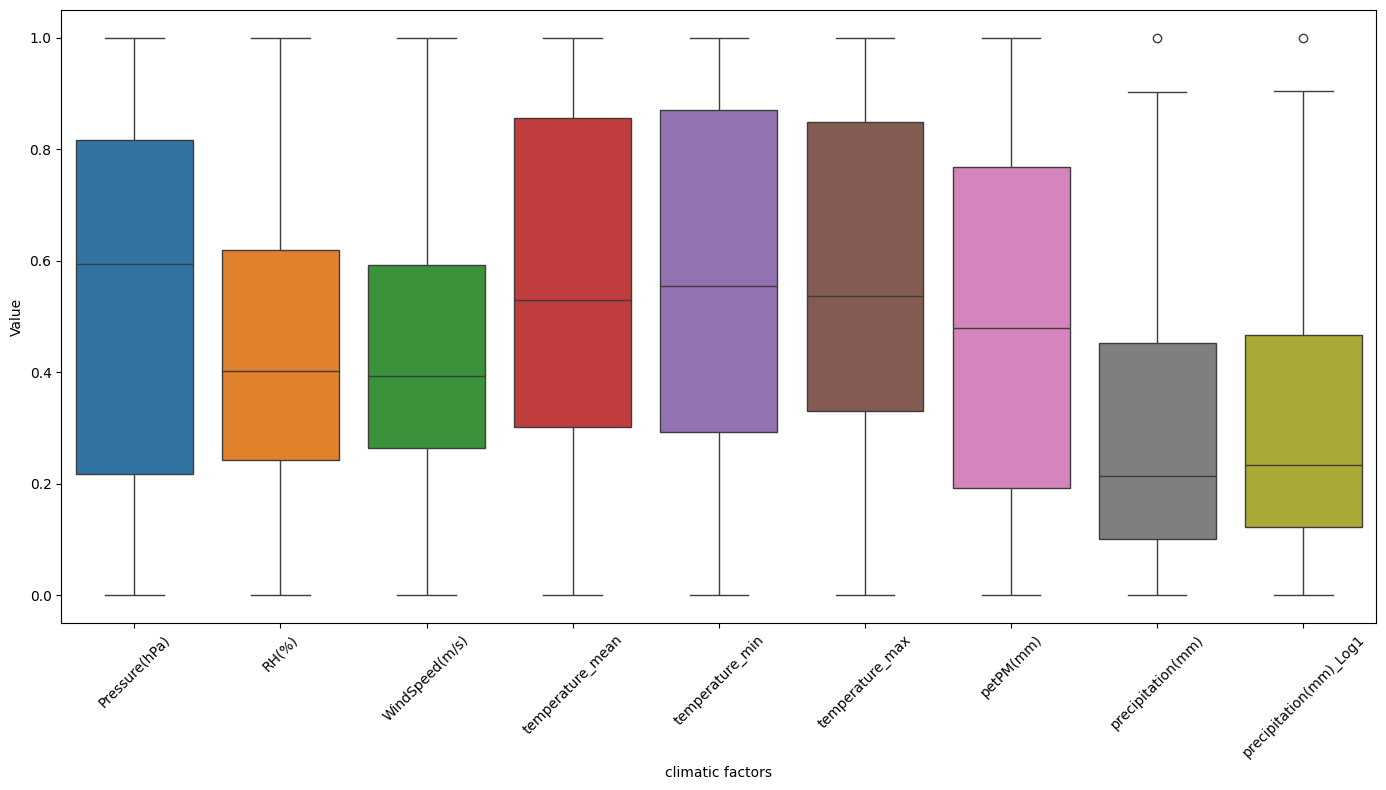

In [20]:
#训练集-气象数据
plt.figure(figsize=(14,8))
sns.boxplot(data=TrainClimate)
plt.xticks(rotation=45)
plt.xlabel('climatic factors')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

In [21]:
#测试集-气象数据
TestClimate.describe()

,Pressure(hPa),RH(%),WindSpeed(m/s),temperature_mean,temperature_min,temperature_max,petPM(mm),precipitation(mm),precipitation(mm)_Log1
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,0.478348,0.307726,0.560804,0.547781,0.544123,0.565599,0.531781,0.238978,0.260919
std,0.300212,0.393519,0.293337,0.358447,0.353089,0.352413,0.364941,0.216536,0.208452
min,-0.002488,-0.271197,0.227706,-0.024098,-0.013289,0.009745,0.014447,0.009882,0.035003
25%,0.293766,0.071999,0.298509,0.385894,0.371386,0.424363,0.267993,0.088726,0.114069
50%,0.524796,0.231587,0.507864,0.571932,0.554661,0.598768,0.584642,0.145209,0.166897
75%,0.685244,0.636222,0.735039,0.814615,0.821649,0.813472,0.668190,0.424671,0.439268
max,0.900237,1.051678,1.040790,1.024106,0.995787,1.042481,1.127020,0.617988,0.627681


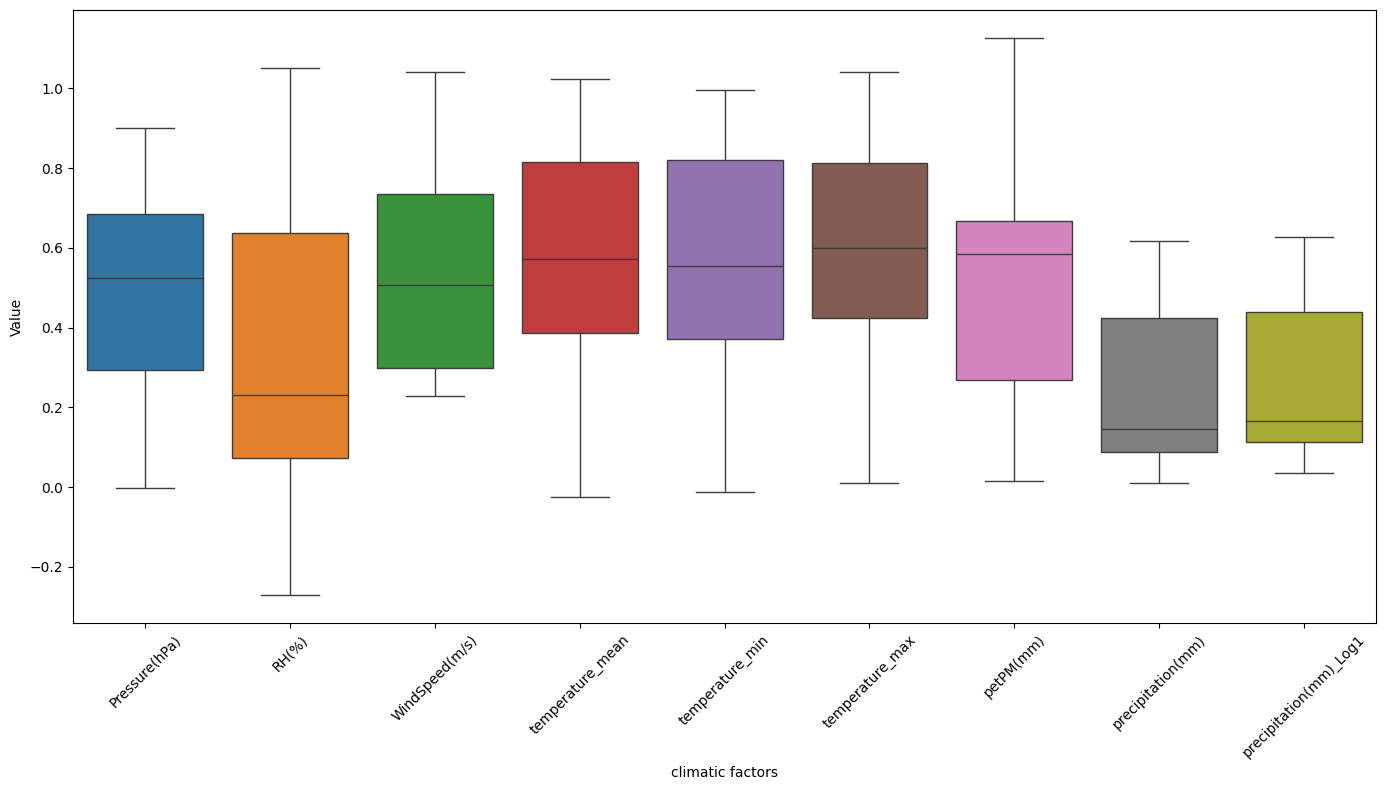

In [22]:
#测试集-气象数据
plt.figure(figsize=(14,8))
sns.boxplot(data=TestClimate)
plt.xticks(rotation=45)
plt.xlabel('climatic factors')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

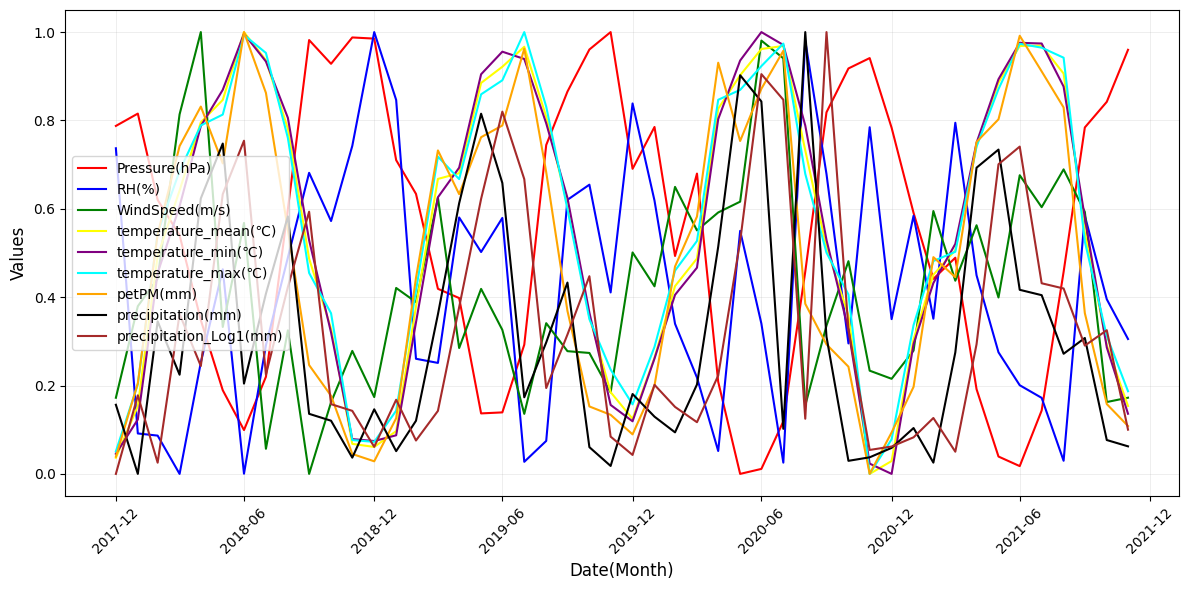

In [23]:
#绘制归一化后气象数据曲线图
fig,ax=plt.subplots(figsize=(12, 6))
ax.plot(TrainClimate.index,TrainClimate['Pressure(hPa)'], label='Pressure(hPa)', color='red',linestyle='-')
ax.plot(TrainClimate.index,TrainClimate['RH(%)'], label='RH(%)', color='blue',linestyle='-')
ax.plot(TrainClimate.index,TrainClimate['WindSpeed(m/s)'], label='WindSpeed(m/s)', color='green',linestyle='-')
ax.plot(TrainClimate.index,TrainClimate['temperature_mean'], label='temperature_mean(℃)', color='yellow',linestyle='-')
ax.plot(TrainClimate.index,TrainClimate['temperature_min'], label='temperature_min(℃)', color='purple',linestyle='-')
ax.plot(TrainClimate.index,TrainClimate['temperature_max'], label='temperature_max(℃)', color='cyan',linestyle='-')
ax.plot(TrainClimate.index,TrainClimate['petPM(mm)'], label='petPM(mm)', color='orange',linestyle='-')
ax.plot(TrainClimate.index,TrainClimate['precipitation(mm)'], label='precipitation(mm)', color='black',linestyle='-')
ax.plot(TrainClimate.index,TrainClimate['precipitation(mm)_Log1'], label='precipitation_Log1(mm)', color='brown',linestyle='-')
date_locator = AutoDateLocator()
date_formatter = DateFormatter("%Y-%m")
ax.xaxis.set_major_locator(date_locator)
ax.xaxis.set_major_formatter(date_formatter)
plt.xticks(rotation=45)
ax.set_title('')
ax.set_xlabel("Date(Month)", fontsize=12)
ax.set_ylabel("Values", fontsize=12)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.show()

进行ARIMA模型参数选择

In [24]:
#获取IR数据
IR=BaseData.loc[:,'IR']

In [25]:
#确定差分阶数d
from statsmodels.tsa.stattools import adfuller
def ADF_test(series,name='series'):
    adf_result=adfuller(series)
    p_value=adf_result[1]
    print(f"ADF Stats:{adf_result[0]:.4f}")
    print(f"p value：{p_value:.4f}")
    print(f"threshold value：{adf_result[4]}")
    if p_value < 0.05:
        print(f"{name} 平稳（p<0.05）")
    else:
        print(f"{name} 非平稳（p≥0.05）")
    print("-"*50)
    return p_value

In [26]:
#计算差分阶数
import numpy as np
d=0
current_series=IR.copy()
max_d=5 
#逐步差分并检验平稳性
while d<=max_d:
    p_value=ADF_test(current_series, name=f"{d}阶差分序列（原始序列d=0）")
    if p_value<0.05:
        break
    else:
        current_series=np.diff(current_series,n=d)
        d+=1
print(f"最终确定最小差分阶数d={d}")

ADF Stats:-4.7779
p value：0.0001
threshold value：{'1%': np.float64(-3.548493559596539), '5%': np.float64(-2.912836594776334), '10%': np.float64(-2.594129155766944)}
0阶差分序列（原始序列d=0） 平稳（p<0.05）
--------------------------------------------------
最终确定最小差分阶数d=0


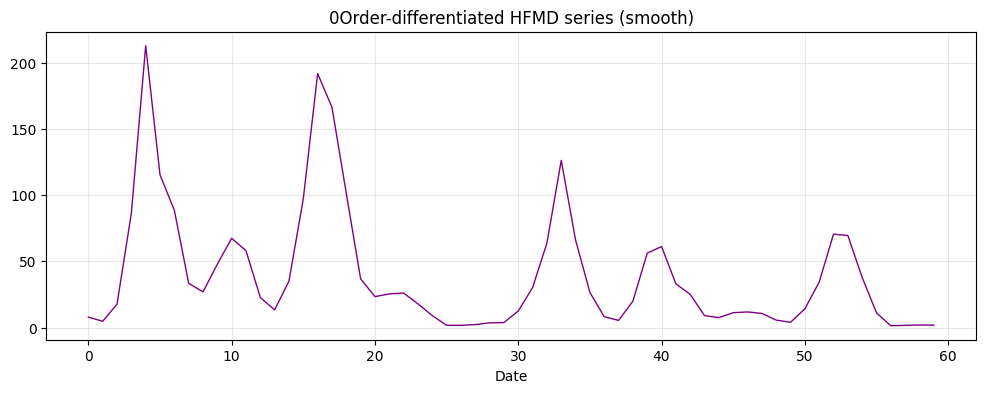

In [27]:
#可视化最终平稳序列
plt.figure(figsize=(12, 4))
plt.plot(current_series, color='purple', linewidth=1)
plt.title(f"{d}Order-differentiated HFMD series (smooth)")
plt.xlabel('Date')
plt.grid(alpha=0.3)
plt.show()

In [28]:
#计算AR模型参数p
from statsmodels.tsa.arima.model import ARIMA
p_max=10
p_candidates=range(0,p_max+1)
aic_ar=[]
smooth_sequence=current_series
for p in p_candidates:
    try:
        ar_model=ARIMA(smooth_sequence,order=(p, 0, 0))
        ar_result=ar_model.fit()
        aic_ar.append(ar_result.aic)
    except:
        aic_ar.append(np.inf)  # 拟合失败时AIC设为无穷大
#获取最小AIC
p_aic_min=p_candidates[np.argmin(aic_ar)]

In [29]:
#AIC值
aic_ar

[np.float64(635.0407028440695),
 np.float64(596.7906554422623),
 np.float64(584.3572884361485),
 np.float64(586.1239593736138),
 np.float64(586.6789327914588),
 np.float64(587.9166350185143),
 np.float64(588.5552746200424),
 np.float64(589.2054343060189),
 np.float64(591.1823556346933),
 np.float64(590.4586425646943),
 np.float64(591.9751095194272)]

In [30]:
#最小AIC
p_aic_min

2

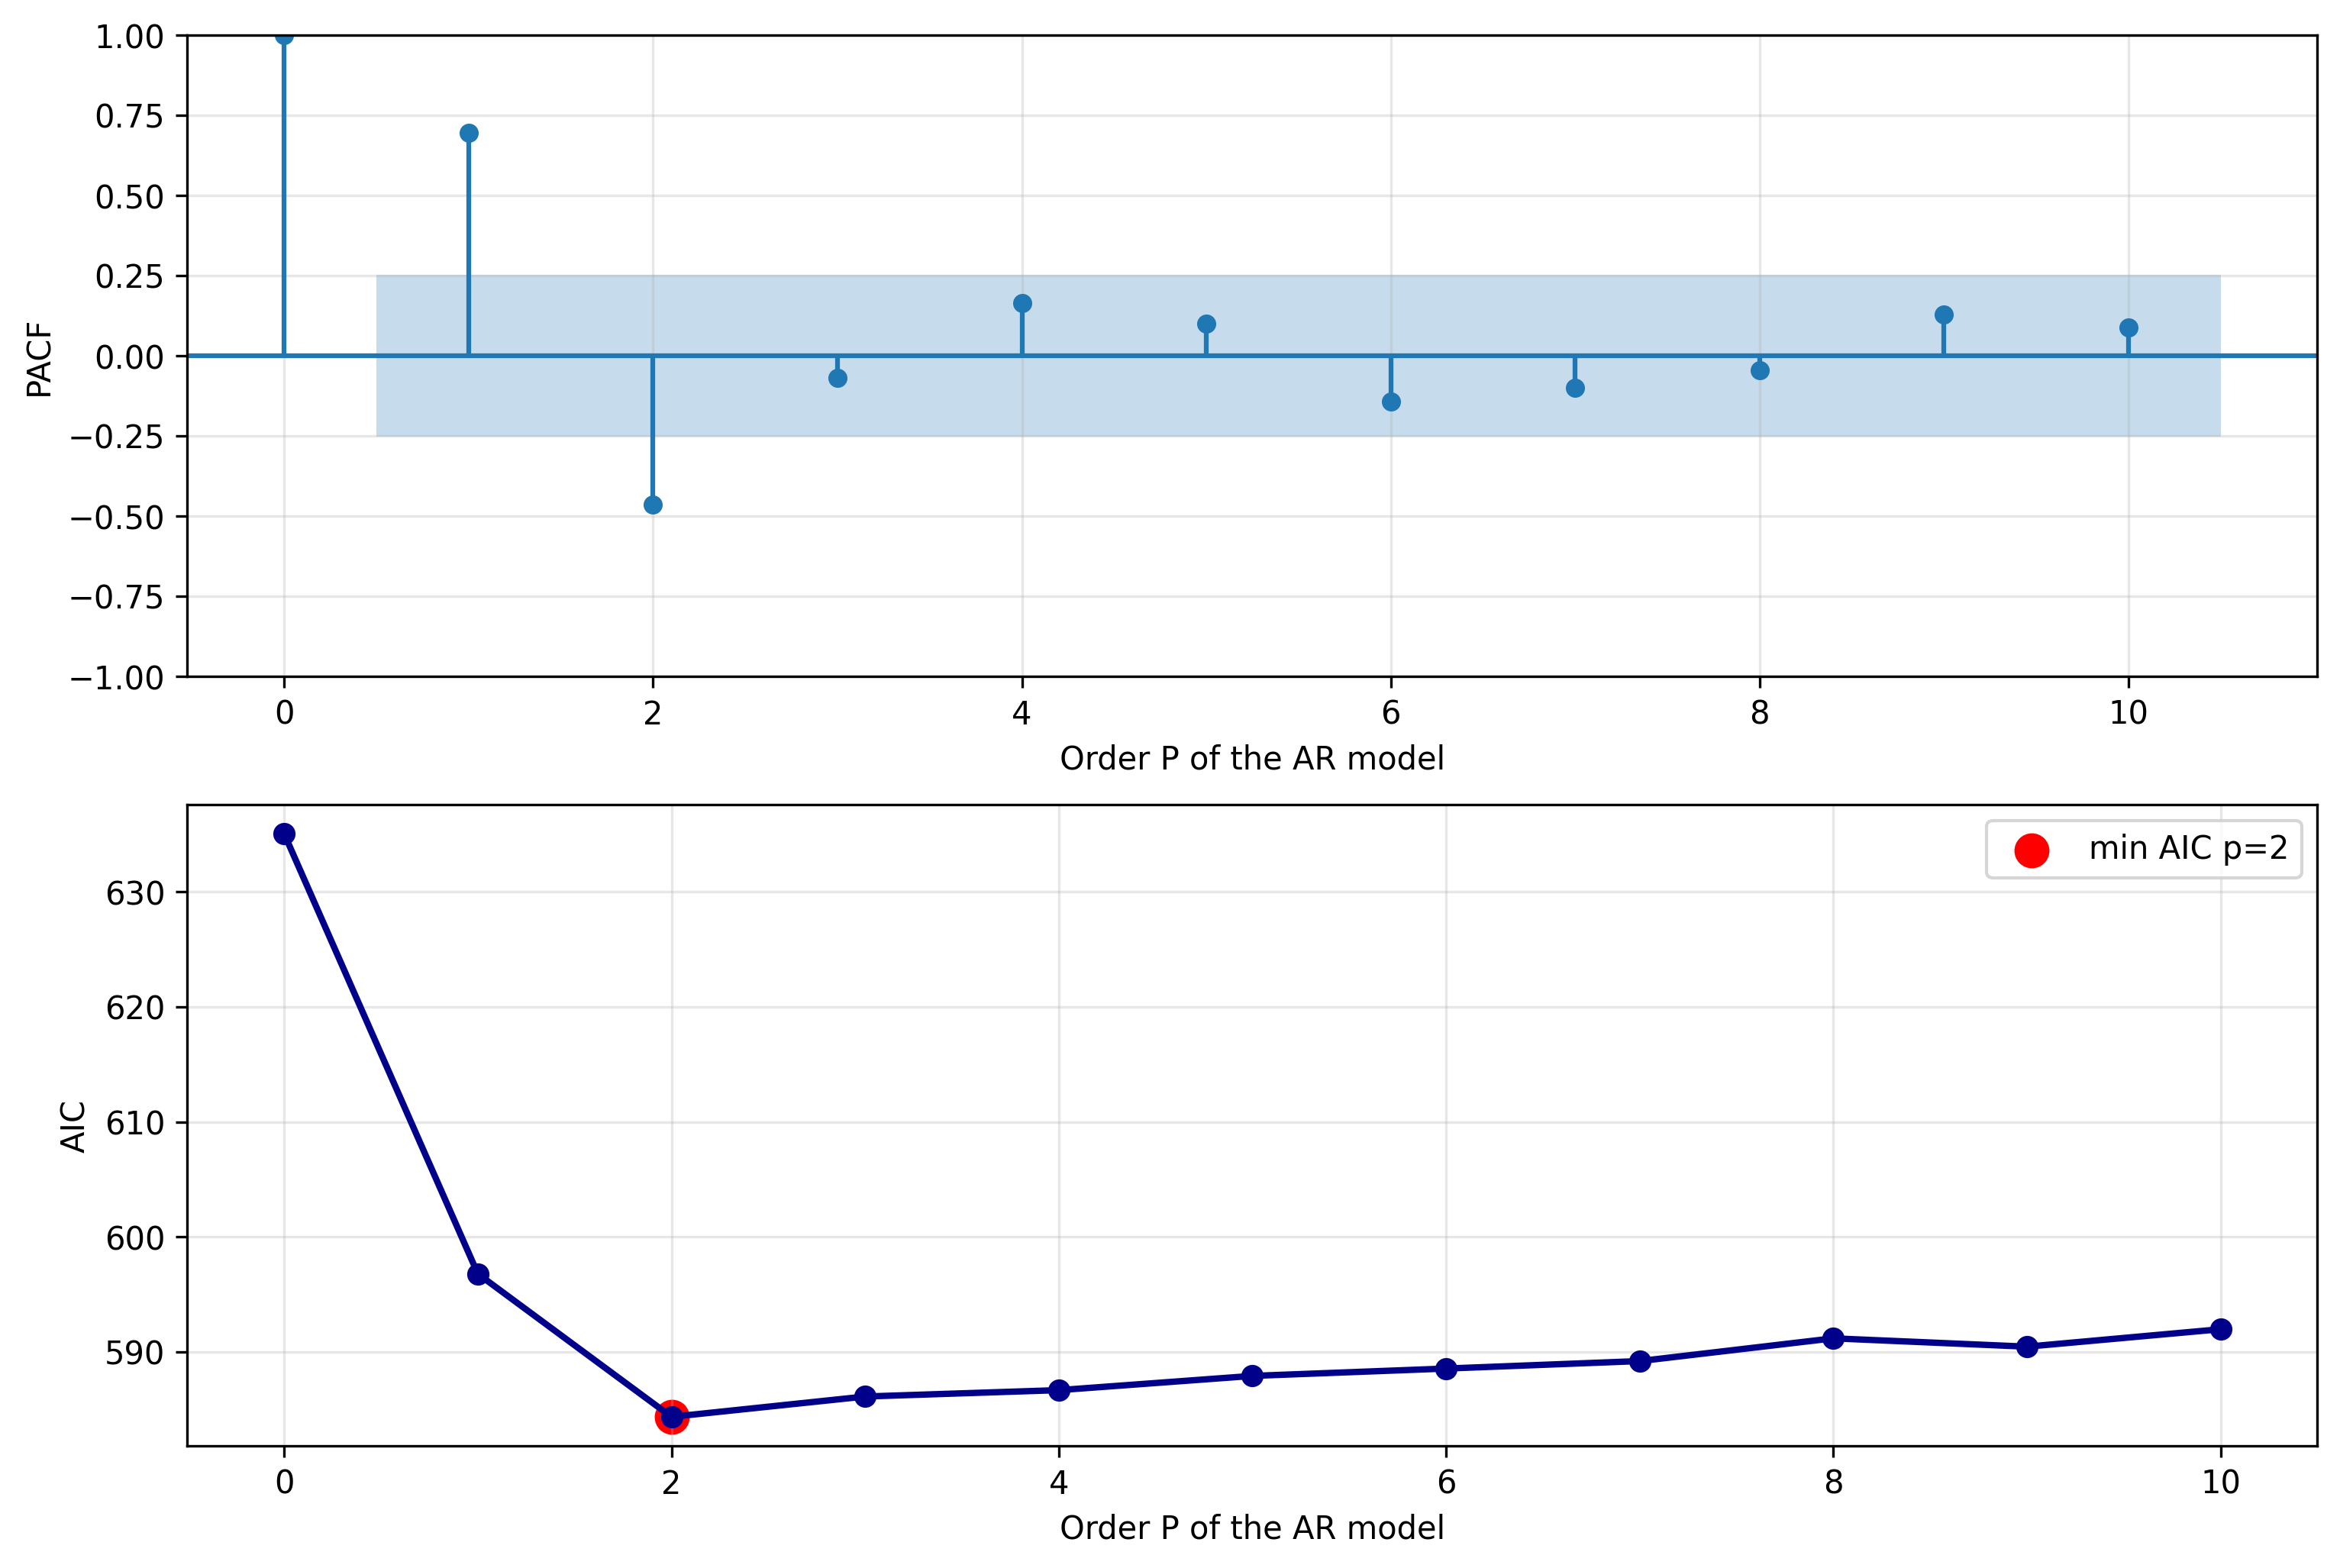

In [31]:
# 4. 绘制PACF图
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
fig1=plt.figure(figsize=(12,8),dpi=300)
ax1=fig1.add_subplot(2,1,1)
plot_pacf(smooth_sequence, lags=10, ax=plt.gca(), alpha=0.05)
ax1.set_ylabel('PACF')
ax1.set_xlabel('Order P of the AR model')
ax1.set_title('')
ax1.grid(alpha=0.3)
#绘制AIC随p变化的趋势图
ax2=fig1.add_subplot(2,1,2)
ax2.plot(p_candidates, aic_ar, marker='o', color='darkblue', linewidth=2)
ax2.scatter(p_aic_min, np.min(aic_ar), color='red', s=100, label=f'min AIC p={p_aic_min}')
ax2.set_xlabel('Order P of the AR model')
ax2.set_ylabel('AIC')
ax2.set_title('')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [32]:
final_p=p_aic_min
print(f"结合AIC最小值和PACF截尾性，最终确定AR阶数p={final_p}")

结合AIC最小值和PACF截尾性，最终确定AR阶数p=2


In [33]:
#计算MA模型参数q
q_max=10
q_candidates=range(0, q_max+1)
aic_ma=[]
smooth_sequenceMA=current_series
for q in q_candidates:
    try:
        ma_model=ARIMA(smooth_sequenceMA, order=(0, 0, q))
        ma_result=ma_model.fit()
        aic_ma.append(ma_result.aic)
    except:
        aic_ma.append(np.inf)
q_aic_min=q_candidates[np.argmin(aic_ma)]

/root/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/root/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/root/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [34]:
#输出AIC
aic_ma

[np.float64(635.0407028440695),
 np.float64(599.3625141304375),
 np.float64(587.3889837193864),
 np.float64(585.7357133001675),
 np.float64(587.728157010489),
 np.float64(586.5672530308974),
 np.float64(589.4268633624357),
 np.float64(593.5652427258494),
 np.float64(590.1680044323466),
 np.float64(593.8788265173583),
 np.float64(589.4520273829552)]

In [35]:
#最小AIC阶数
q_aic_min

3

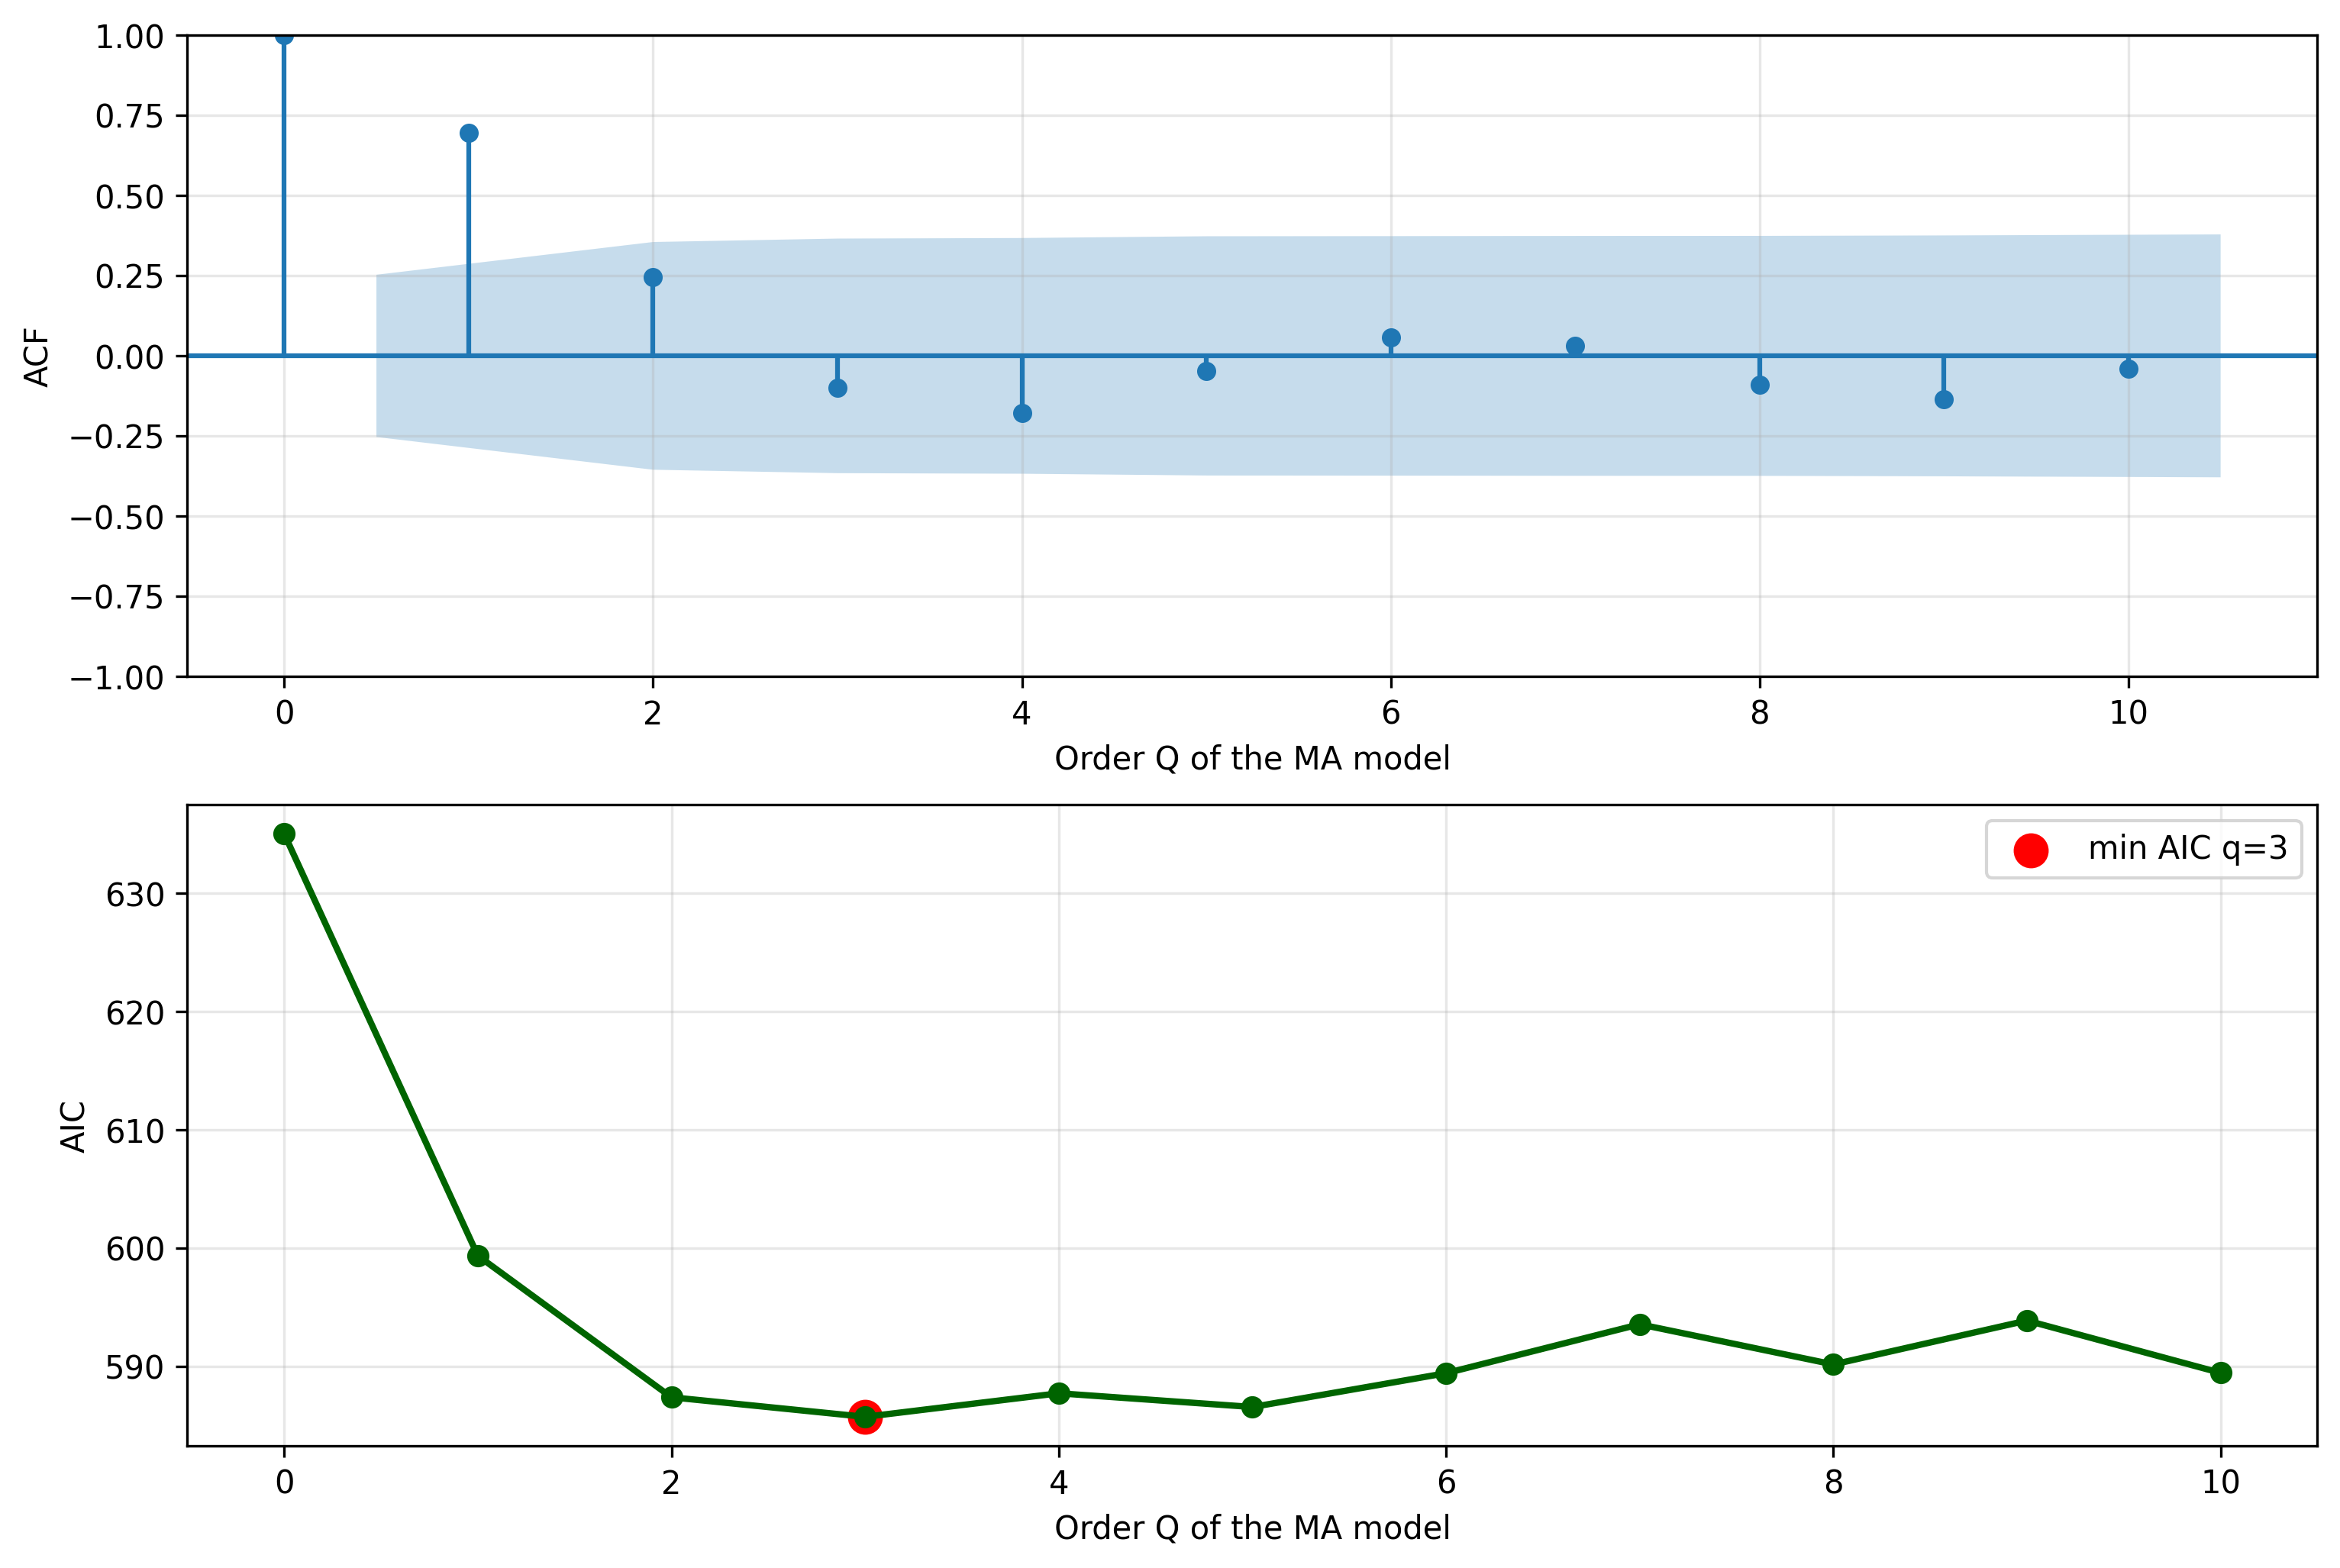

In [36]:
#绘制ACF图
fig=plt.figure(figsize=(12, 8),dpi=300)
ax1=fig.add_subplot(2, 1, 1)
plot_acf(smooth_sequenceMA, lags=10, ax=plt.gca(), alpha=0.05)
ax1.set_xlabel('Order Q of the MA model')
ax1.set_ylabel('ACF')
ax1.set_title('')
ax1.grid(alpha=0.3)
#绘制AIC随q变化的趋势图
ax2=fig.add_subplot(2, 1, 2)
ax2.plot(q_candidates, aic_ma, marker='o', color='darkgreen', linewidth=2)
ax2.scatter(q_aic_min, np.min(aic_ma), color='red', s=100, label=f'min AIC q={q_aic_min}')
ax2.set_xlabel('Order Q of the MA model')
ax2.set_ylabel('AIC')
ax2.set_title('')
plt.legend()
ax2.grid(alpha=0.3)
plt.show()

In [37]:
#结合ACF截尾性确定最终q
final_q = q_aic_min
print(f'结合AIC最小值和ACF截尾性，最终确定MA阶数q={final_q}')

结合AIC最小值和ACF截尾性，最终确定MA阶数q=3


In [38]:
#构建差分阶数
import tqdm
for climate in tqdm.tqdm(Climate_Train.columns):
    climate_data=Climate_Train.loc[:,climate]
    current_series=climate_data
    d=0
    max_d=5 
    #逐步差分并检验平稳性
    while d<=max_d:
        p_value=ADF_test(current_series, name=f"{d}阶差分序列（原始序列d=0）")
        if p_value<0.001:
            break
        else:
            current_series=current_series.shift(d)
            current_series.fillna(0,inplace=True)
        d+=1
    print(f"{climate}最终确定最小差分阶数d={d}")

100%|██████████| 9/9 [00:00<00:00, 314.26it/s]

ADF Stats:-0.3431
p value：0.9192
threshold value：{'1%': np.float64(-3.6209175221605827), '5%': np.float64(-2.9435394610388332), '10%': np.float64(-2.6104002410518627)}
0阶差分序列（原始序列d=0） 非平稳（p≥0.05）
--------------------------------------------------
ADF Stats:-0.3431
p value：0.9192
threshold value：{'1%': np.float64(-3.6209175221605827), '5%': np.float64(-2.9435394610388332), '10%': np.float64(-2.6104002410518627)}
1阶差分序列（原始序列d=0） 非平稳（p≥0.05）
--------------------------------------------------
ADF Stats:-2.7959
p value：0.0589
threshold value：{'1%': np.float64(-3.6155091011809297), '5%': np.float64(-2.941262357486514), '10%': np.float64(-2.6091995013850418)}
2阶差分序列（原始序列d=0） 非平稳（p≥0.05）
--------------------------------------------------
ADF Stats:-4.2713
p value：0.0005
threshold value：{'1%': np.float64(-3.6155091011809297), '5%': np.float64(-2.941262357486514), '10%': np.float64(-2.6091995013850418)}
3阶差分序列（原始序列d=0） 平稳（p<0.05）
--------------------------------------------------
Pressure(hPa)最终

拟合ARIMA系列模型

In [ ]:
#对ARIMA模型进行拟合_ARIMA(2,0,3)
from statsmodels.tsa.arima.model import ARIMA
ARIMA_model1=ARIMA(HFMDIR_Train, order=(2,0,3))
ARIMA_fit1=ARIMA_model1.fit()

In [39]:
#读取ARIMA模型
import joblib
ARIMA_fit1=joblib.load('/root/ToResult/AutoTS/ARIMA(2,0,3).joblib')

In [40]:
ARIMA_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                     IR   No. Observations:                   48
Model:                 ARIMA(2, 0, 3)   Log Likelihood                -232.561
Date:                Fri, 15 May 2026   AIC                            479.122
Time:                        10:50:08   BIC                            492.220
Sample:                    01-01-2018   HQIC                           484.072
                         - 12-01-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         44.4162     19.756      2.248      0.025       5.695      83.138
ar.L1          0.1545      0.530      0.291      0.771      -0.885       1.194
ar.L2         -0.4748      0.256     -1.858      0.063      -0.976       0.026
ma.L1          0.8029      0.754      1.065      0.287      -0.674       2.280
ma.L2          1.1174      3.510      0.318      0.750      -5.762       7.997
ma.L3          0.5931      2.168      0.274      0.784      -3.655       4.842
sigma2       847.4054   2728.928      0.311      0.756   -4501.195    6196.006
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                27.43
Prob(Q):                              0.83   Prob(JB):                         0.00
Heteroskedasticity (H):               0.34   Skew:                             1.25
Prob(H) (two-sided):                  0.04   Kurtosis:                         5.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [41]:
#定义评估函数
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"MAE:{mae:.4f}")
    print(f"RMSE:{rmse:.4f}")
    return mae, rmse

In [42]:
#评估ARIMA模型效果_训练集
train_pred1=ARIMA_fit1.predict('2018-01-01','2021-12-01')
ARIMA1_MAE_train,ARIMA1_MSE_train=evaluate_model(y_true=HFMDIR_Train, y_pred=train_pred1)

MAE:21.9009
RMSE:31.5007


In [43]:
#评估ARIMA模型效果-测试集
test_pred1=ARIMA_fit1.predict('2022-01','2022-12')
ARIMA1_MAE_test,ARIMA1_MSE_test=evaluate_model(y_true=HFMDIR_Test, y_pred=test_pred1)

MAE:32.4090
RMSE:35.0362


In [40]:
#保存模型
import joblib
joblib.dump(ARIMA_fit1,'/root/ToResult/AutoTS/ARIMA(2,0,3).joblib')

['/root/ToResult/AutoTS/ARIMA(2,0,3).joblib']

In [ ]:
#对ARIMA模型进行拟合_ARIMA(2,1,3)
ARIMA_model2=ARIMA(HFMDIR_Train, order=(2,1,3))
ARIMA_fit2=ARIMA_model2.fit()

In [44]:
#读取ARIMA(2,1,3)模型
ARIMA_fit2=joblib.load('/root/ToResult/AutoTS/ARIMA(2,1,3).joblib')

In [45]:
ARIMA_fit2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                     IR   No. Observations:                   48
Model:                 ARIMA(2, 1, 3)   Log Likelihood                -229.846
Date:                Fri, 15 May 2026   AIC                            471.691
Time:                        10:50:24   BIC                            482.792
Sample:                    01-01-2018   HQIC                           475.869
                         - 12-01-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9446      0.256      3.692      0.000       0.443       1.446
ar.L2         -0.6657      0.218     -3.055      0.002      -1.093      -0.239
ma.L1         -1.0160      0.344     -2.949      0.003      -1.691      -0.341
ma.L2          0.5463      0.371      1.472      0.141      -0.181       1.274
ma.L3         -0.3967      0.306     -1.296      0.195      -0.997       0.203
sigma2       994.4835    218.443      4.553      0.000     566.343    1422.624
===================================================================================
Ljung-Box (L1) (Q):                   0.28   Jarque-Bera (JB):                25.80
Prob(Q):                              0.59   Prob(JB):                         0.00
Heteroskedasticity (H):               0.27   Skew:                             1.05
Prob(H) (two-sided):                  0.01   Kurtosis:                         5.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [46]:
#评估ARIMA模型效果_训练集
train_pred2=ARIMA_fit2.predict('2018-01-01','2021-12-01')
ARIMA2_MAE_train,ARIMA2_MSE_train=evaluate_model(y_true=HFMDIR_Train, y_pred=train_pred2)

MAE:22.8752
RMSE:32.6198


In [47]:
test_pred2=ARIMA_fit2.predict('2022-01','2022-12')
ARIMA2_MAE_test,ARIMA2_MSE_test=evaluate_model(y_true=HFMDIR_Test, y_pred=test_pred2)

MAE:22.2132
RMSE:25.0243


In [45]:
#保存模型
import joblib
joblib.dump(ARIMA_fit2,'/root/ToResult/AutoTS/ARIMA(2,1,3).joblib')

['/root/ToResult/AutoTS/ARIMA(2,1,3).joblib']

拟合ARIMAX模型,利用SHAP计算特征重要性。

In [52]:
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')
sarima_order=(2,1,3)  # 非季节性参数(p,d,q)
sarima_seasonal_order=(1, 0, 1, 12)  # 季节性参数(P,D,Q,s)
# 构建并拟合SARIMA模型
ARIMAX_model=SARIMAX(HFMDIR_Train,exog=TrainClimate,order=sarima_order,seasonal_order=sarima_seasonal_order,
                     enforce_stationarity=False,enforce_invertibility=False)
ARIMAX_fit=ARIMAX_model.fit()

In [48]:
#读取ARIMAX模型
ARIMAX_fit=joblib.load('/root/ToResult/AutoTS/ARIMAX(2,1,3).joblib')

In [49]:
#评估ARIMAX模型效果_训练集
train_predX=ARIMAX_fit.predict('2018-01-01','2021-12-01')
ARIMAX_MAE_train,ARIMAX_MSE_train=evaluate_model(y_true=HFMDIR_Train, y_pred=train_predX)

MAE:29.3333
RMSE:40.4265


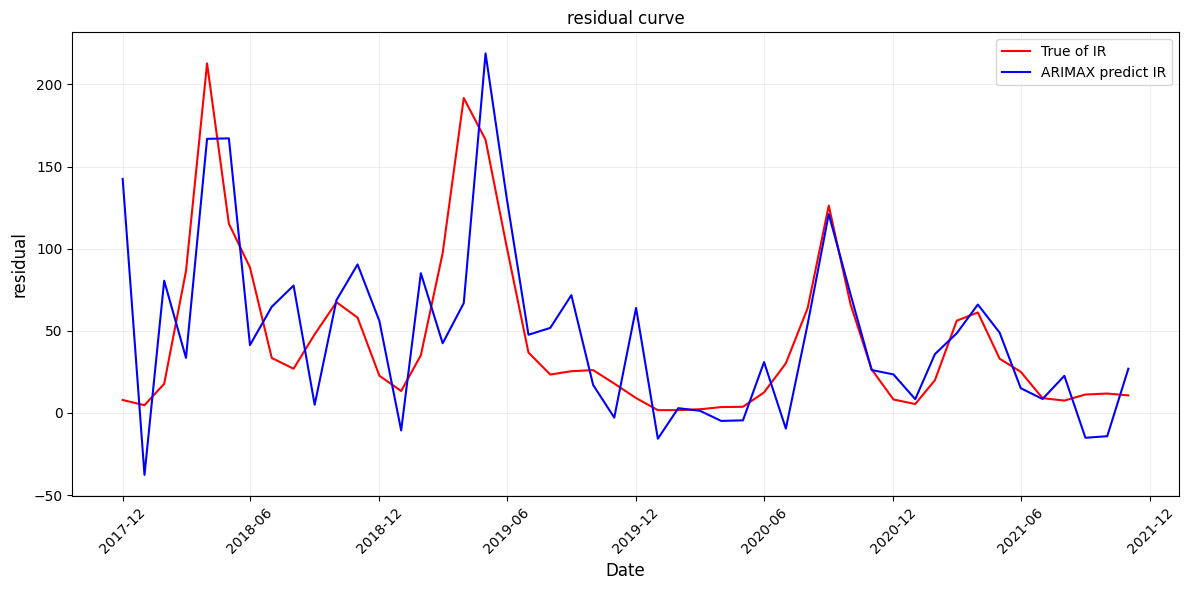

In [50]:
fig,ax=plt.subplots(figsize=(12, 6))
ax.plot(HFMDIR_Train.index,HFMDIR_Train, label='True of IR', color='red',linestyle='-')
ax.plot(HFMDIR_Train.index,train_predX, label='ARIMAX predict IR', color='blue',linestyle='-')
date_locator = AutoDateLocator()
date_formatter = DateFormatter("%Y-%m")
ax.xaxis.set_major_locator(date_locator)
ax.xaxis.set_major_formatter(date_formatter)
plt.xticks(rotation=45)
ax.set_title('residual curve')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("residual", fontsize=12)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.show()

In [51]:
#评估ARIMAX模型效果_测试集
test_predX=ARIMAX_fit.predict('2022-01-01','2022-12-01',exog=TestClimate)
ARIMAX_MAE_test,ARIMAX_MSE_test=evaluate_model(y_true=HFMDIR_Test, y_pred=test_predX)

MAE:29.5483
RMSE:35.1876


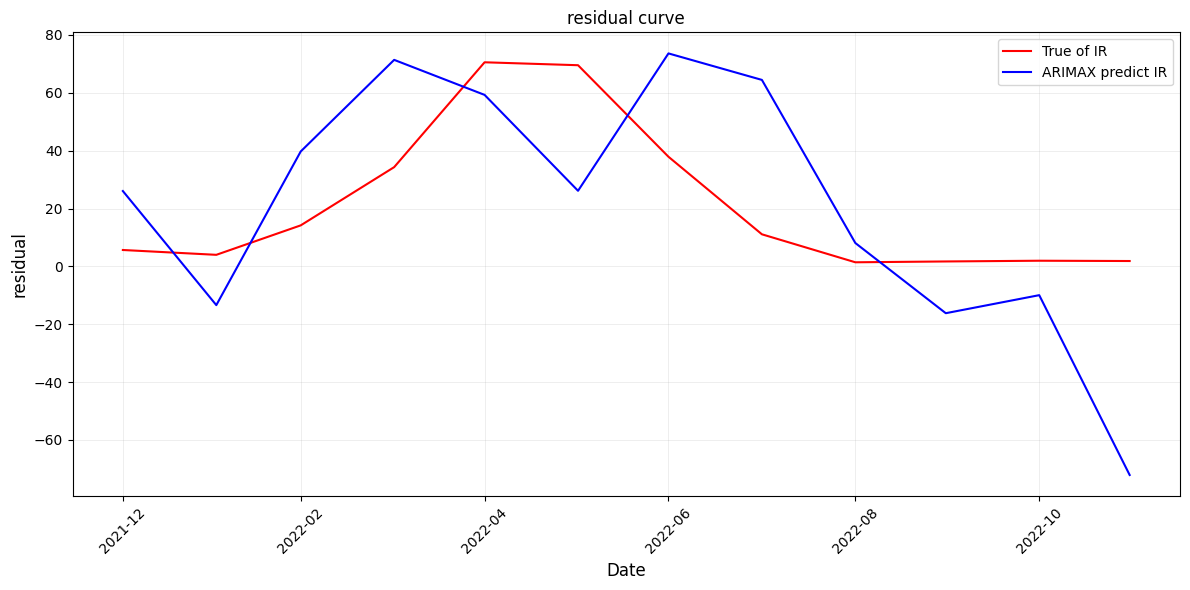

In [52]:
fig,ax=plt.subplots(figsize=(12, 6))
ax.plot(HFMDIR_Test.index,HFMDIR_Test, label='True of IR', color='red',linestyle='-')
ax.plot(HFMDIR_Test.index,test_predX, label='ARIMAX predict IR', color='blue',linestyle='-')
date_locator = AutoDateLocator()
date_formatter = DateFormatter("%Y-%m")
ax.xaxis.set_major_locator(date_locator)
ax.xaxis.set_major_formatter(date_formatter)
plt.xticks(rotation=45)
ax.set_title('residual curve')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("residual", fontsize=12)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.show()

In [57]:
#保存模型
import joblib
joblib.dump(ARIMAX_fit,'/root/ToResult/AutoTS/ARIMAX(2,1,3).joblib')

['/root/ToResult/AutoTS/ARIMAX(2,1,3).joblib']

采用SHAP计算SHAP Value值，量化气象因素与HFMD之间的重要性。

In [56]:
#编写预测函数
def arimax_predict_fn(exog_data):
    if not isinstance(exog_data, pd.DataFrame):
        exog_data = pd.DataFrame(exog_data, columns=exog_features)
    # ARIMAX预测（动态预测，forecast_steps=1）
    preds = []
    for idx in range(len(exog_data)):
        exog_sample = exog_data.iloc[idx:idx+1]
        pred =ARIMAX_fit.get_forecast(steps=1, exog=exog_sample).predicted_mean.values[0]
        preds.append(pred)
    return np.array(preds)

In [58]:
#计算SHAP
import shap
exog_features=TrainClimate.columns
explainer=shap.KernelExplainer(model=arimax_predict_fn, data=TrainClimate,link="identity")
shap_values=explainer.shap_values(X=TrainClimate,nsamples=50)

  0%|          | 0/48 [00:00<?, ?it/s]

In [59]:
shap_explainer = shap.Explanation(values=shap_values,base_values=explainer.expected_value,data=TrainClimate,
                                  feature_names=exog_features)

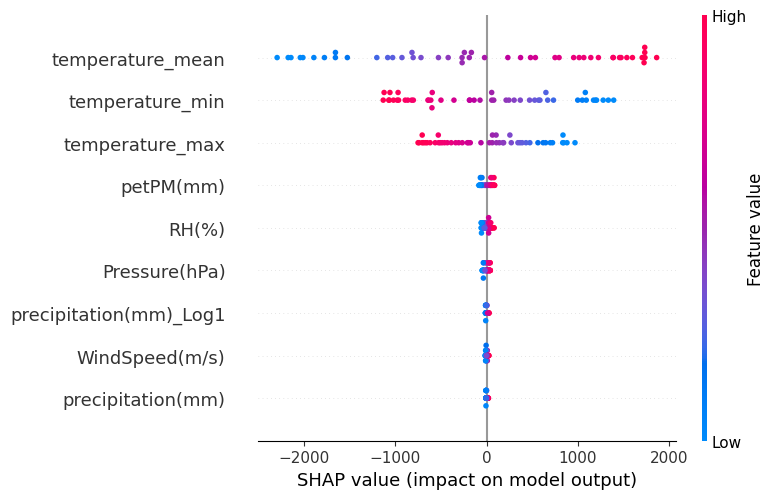

In [60]:
shap.summary_plot(shap_values,features=TrainClimate,
                  feature_names=exog_features,plot_type="dot",show=True)

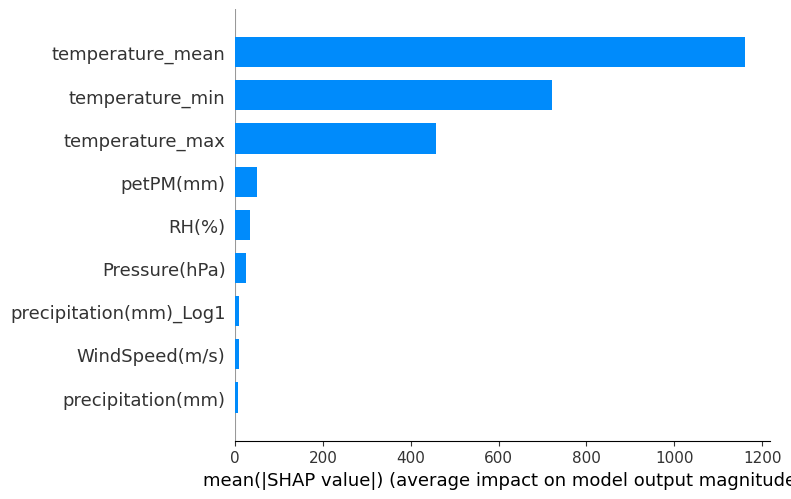

In [61]:
shap.summary_plot(shap_values,features=TrainClimate,
                  feature_names=exog_features,plot_type="bar",show=True)

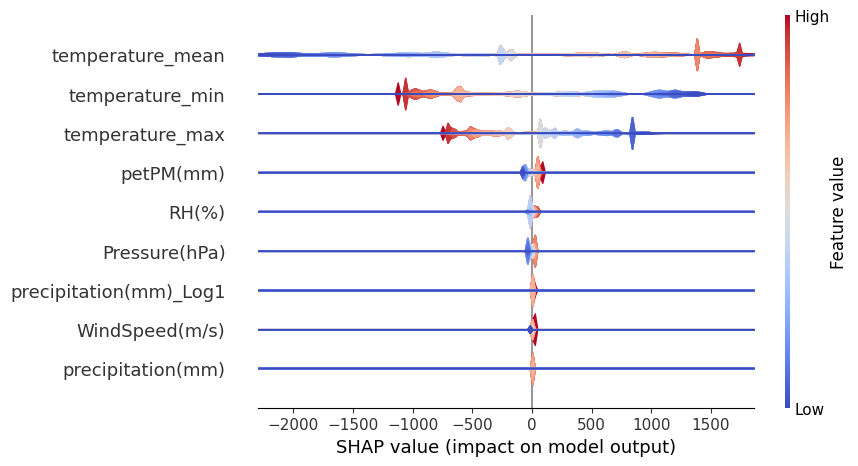

In [62]:
shap.plots.violin(shap_values, features=TrainClimate, feature_names=exog_features, plot_type="layered_violin")

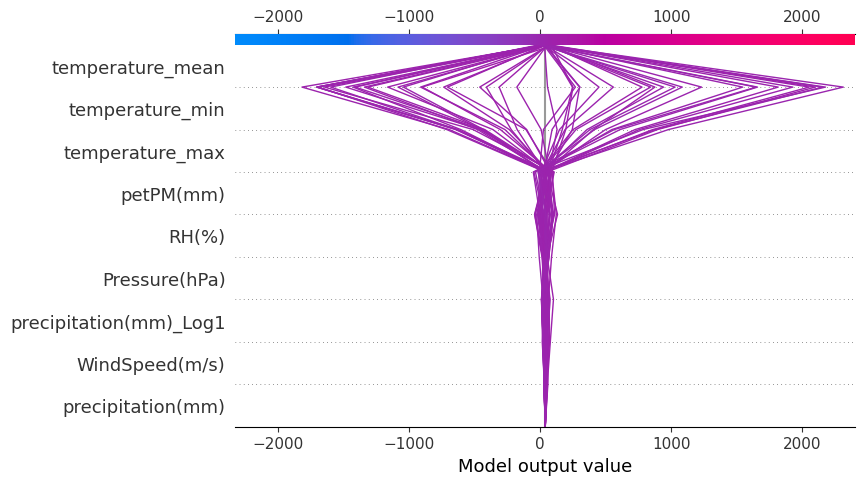

In [63]:
expected_value = explainer.expected_value
shap.decision_plot(expected_value,shap_values,exog_features)

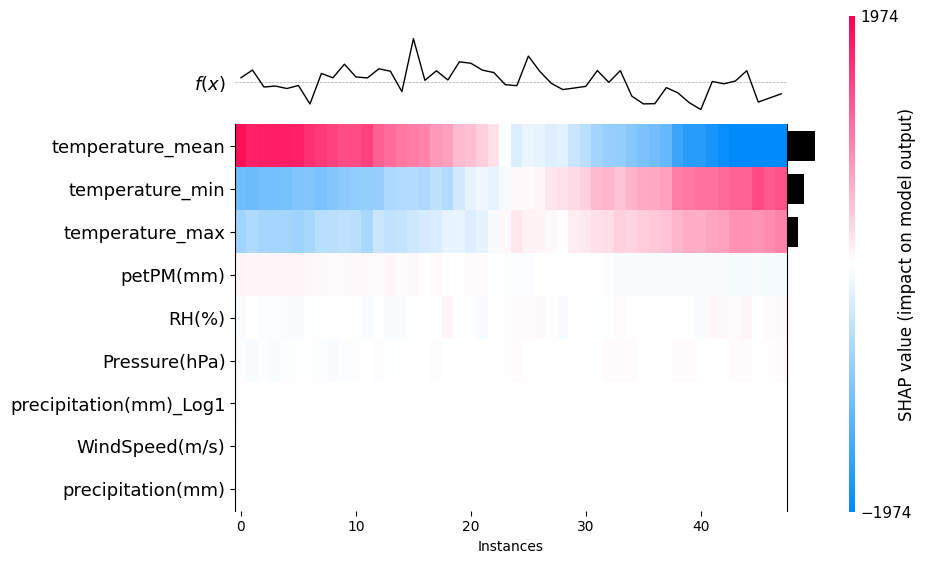

<Axes: xlabel='Instances'>

In [64]:
shap.plots.heatmap(shap_explainer)

In [65]:
SHAP=DataFrame(shap_values)
SHAP.columns=TrainClimate.columns
SHAP.to_csv('/root/ToResult/AutoTS/SHAPResult.csv',encoding='utf-8')

再次训练ARIMAX模型，采用SHAP拟合结果叠加经验结果。

In [53]:
#构建气象数据
SHAP_feature=['temperature_mean','temperature_min', 'temperature_max','petPM(mm)','precipitation(mm)','precipitation(mm)_Log1']
Train_exog=TrainClimate.loc[:,SHAP_feature]
#训练标签：HFMDIR_Train
Test_exog=TestClimate.loc[:,SHAP_feature]
#测试标签：HFMDIR_Test

In [60]:
#再次训练ARIMAX模型
sarima_order=(2,1,3)
sarima_seasonal_order=(1, 0, 1, 12)
# 构建并拟合SARIMA模型
ARIMAX_SHAP=SARIMAX(HFMDIR_Train,exog=Train_exog,order=sarima_order,seasonal_order=sarima_seasonal_order,
                     enforce_stationarity=False,enforce_invertibility=False)
ARIMAX_SHAP=ARIMAX_SHAP.fit()

In [54]:
#读取ARIMAX——SHAP模型
ARIMAX_SHAP=joblib.load('/root/ToResult/AutoTS/ARIMAX_SHAP(2,1,3).joblib')

In [55]:
#评估ARIMAX模型效果_训练集
train_predSHAPX=ARIMAX_SHAP.predict('2018-01-01','2021-12-01')
ARIMAX_MAE_train_SHAP,ARIMAX_MSE_train_SHAP=evaluate_model(y_true=HFMDIR_Train, y_pred=train_predSHAPX)

MAE:27.5285
RMSE:36.7288


In [56]:
#评估ARIMAX模型效果_测试集
test_predSHAPX=ARIMAX_SHAP.predict('2022-01-01','2022-12-01',exog=Test_exog)
ARIMAX_MAE_test_SHAP,ARIMAX_MSE_test_SHAP=evaluate_model(y_true=HFMDIR_Test, y_pred=test_predSHAPX)

MAE:13.2783
RMSE:18.7804


In [63]:
#保存模型
import joblib
joblib.dump(ARIMAX_SHAP,'/root/ToResult/AutoTS/ARIMAX_SHAP(2,1,3).joblib')

['/root/ToResult/AutoTS/ARIMAX_SHAP(2,1,3).joblib']

SARIMA模型，提取残差用SARIMA拟合HFMD的趋势与季节性，计算训练集残差，并得到测试集的 SARIMA 预测值。

In [64]:
#拟合SARIMA模型
SARIMA_ML=SARIMAX(HFMDIR_Train,order=sarima_order,
                  seasonal_order=sarima_seasonal_order,enforce_stationarity=False,enforce_invertibility=False)
SARIMA_ML_fit=SARIMA_ML.fit()

In [57]:
#读取SARIMA模型
SARIMA_ML_fit=joblib.load('/root/ToResult/AutoTS/SARIMA(2,1,3).joblib')

In [58]:
#获取模型预测值和残差
from pandas import DataFrame
df_train=DataFrame()
df_train['IR']=HFMDIR_Train
df_train.index=HFMDIR_Train.index
#训练集模型对应历史数据的拟合
df_train['sarima_fit']=SARIMA_ML_fit.predict('2018-01-01','2021-12-01')
#训练集残差（真实值-SARIMA拟合值）
df_train['residual']=df_train['IR']-df_train['sarima_fit']

In [59]:
#ADF检验
ADF_test(series=df_train['residual'],name='series')

ADF Stats:-12.6054
p value：0.0000
threshold value：{'1%': np.float64(-3.5778480370438146), '5%': np.float64(-2.925338105429433), '10%': np.float64(-2.6007735310095064)}
series 平稳（p<0.05）
--------------------------------------------------


np.float64(1.7003396617193446e-23)

In [60]:
#查看SARIMA模型效果-训练集残差统计
print(f"残差均值：{df_train['residual'].mean():.4f}")
print(f"残差标准差：{df_train['residual'].std():.4f}")

残差均值：0.0263
残差标准差：45.8098


In [61]:
#预测测试集的SARIMA值
arima_test_pred=SARIMA_ML_fit.predict('2022-01','2022-12',exog=TestClimate.loc[:,SHAP_feature])
df_test=DataFrame()
df_test['IR']=HFMDIR_Test
df_test.index=HFMDIR_Test.index
df_test['sarima_fit']=arima_test_pred.values
#训练集残差（真实值-SARIMA拟合值）
df_test['residual']=df_test['IR']-df_test['sarima_fit']

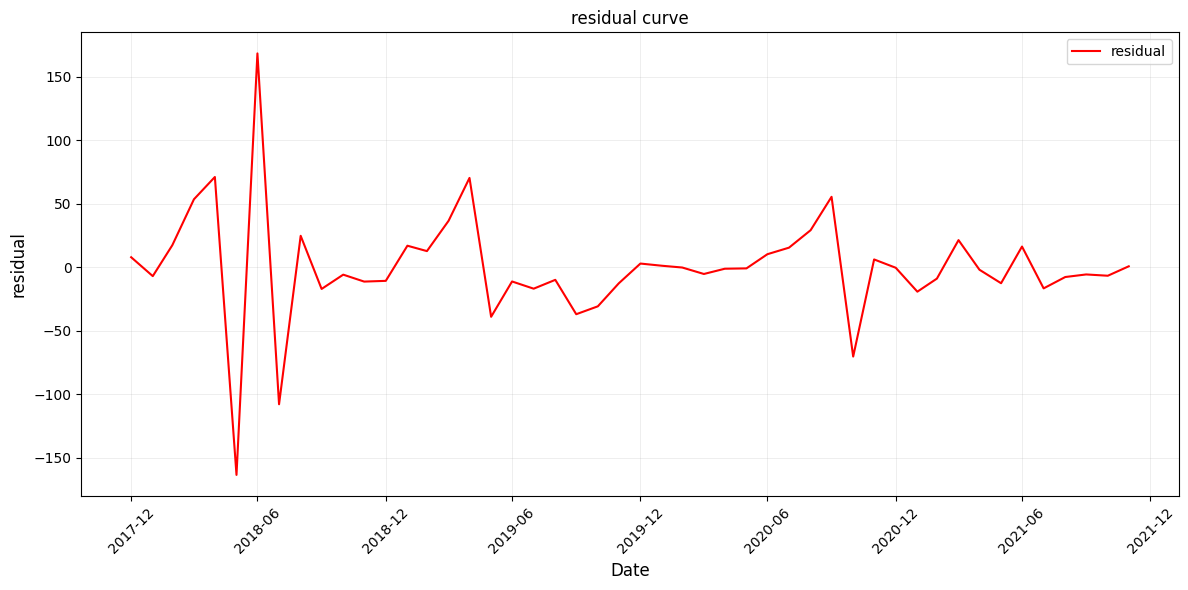

In [62]:
fig,ax=plt.subplots(figsize=(12, 6))
ax.plot(df_train.index,df_train['residual'], label='residual', color='red',linestyle='-')
date_locator = AutoDateLocator()
date_formatter = DateFormatter("%Y-%m")
ax.xaxis.set_major_locator(date_locator)
ax.xaxis.set_major_formatter(date_formatter)
plt.xticks(rotation=45)
ax.set_title('residual curve')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("residual", fontsize=12)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.show()

In [63]:
#准备XGBoost训练数据
X_train=TrainClimate.loc[:,SHAP_feature]
y_train=df_train['residual']
X_test=TestClimate.loc[:,SHAP_feature]

In [64]:
#构建XGBoost模型
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV,TimeSeriesSplit,RandomizedSearchCV
param_grid={'n_estimators': [50, 100, 200, 300],'max_depth': [3, 5, 7, 9],'learning_rate':[0.01, 0.3,0.5],
            'gamma': [0, 0.1, 0.5, 1, 2],'reg_alpha': [0, 0.1, 1, 10],'reg_lambda': [1, 5, 10, 20],
            'subsample': [0.7, 0.8, 0.9, 1.0],  'colsample_bytree': [0.7, 0.8, 0.9, 1.0]} 
ts_cv=TimeSeriesSplit(n_splits=5)
#训练XGBoost模型
xgb_model=XGBRegressor(objective='reg:squarederror',n_jobs=-1,random_state=42)
# 初始化随机搜索
random_search = RandomizedSearchCV(estimator=xgb_model,param_distributions=param_grid,n_iter=100,
                                   cv=ts_cv,scoring='neg_mean_squared_error', refit=True,verbose=1,
                                   random_state=42,n_jobs=-1)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.3, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can

In [65]:
#提取最佳结果
best_params=random_search.best_params_
best_score=-random_search.best_score_
best_model=random_search.best_estimator_
print(f"最佳参数组合:{best_params}")
print(f"最佳MSE:{best_score:.4f}")

最佳参数组合:{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8}
最佳MSE:506.2081


In [66]:
#读取XGBoost模型
best_model=joblib.load('/root/ToResult/AutoTS/XGBoost.joblib')

/root/miniconda3/lib/python3.12/pickle.py:1710: UserWarning: [10:51:36] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


In [67]:
#预测残差
df_train['xgb_residual_fit']=best_model.predict(X_train)
df_test['xgb_residual_fit']=best_model.predict(X_test)

In [68]:
#训练集_XGBoost
evaluate_model(y_true=df_train['residual'], y_pred=df_train['xgb_residual_fit'])

MAE:21.1424
RMSE:36.8942


(21.142408683034127, np.float64(36.89420245484019))

In [69]:
#测试集_XGBoost
evaluate_model(y_true=df_test['residual'], y_pred=df_test['xgb_residual_fit'])

MAE:19.1765
RMSE:31.2977


(19.1764869097343, np.float64(31.297728330353806))

合并ARIMA预测值与XGBoost残差预测值，得到最终预测结果，并与单独 SARIMA 模型对比评估。

In [70]:
#计算混合模型的最终预测值
#训练集
df_train['hybrid_fit']=df_train['sarima_fit']+df_train['xgb_residual_fit']
#测试集
df_test['hybrid_pred']=df_test['sarima_fit']+df_test['xgb_residual_fit']

In [71]:
# 单独SARIMA模型评估-训练集
evaluate_model(y_true=df_train['IR'], y_pred=df_train['sarima_fit'])

MAE:26.6145
RMSE:45.3302


(26.614498374699128, np.float64(45.330153227774424))

In [72]:
#混合模型评估-训练集
evaluate_model(y_true=df_train['IR'], y_pred=df_train['hybrid_fit'])

MAE:21.1424
RMSE:36.8942


(21.14240868303413, np.float64(36.89420245484019))

In [73]:
# 单独ARIMA模型评估-测试集
evaluate_model(y_true=df_test['IR'], y_pred=df_test['sarima_fit'])

MAE:18.2633
RMSE:27.6560


(18.263341686063466, np.float64(27.65600569203814))

In [74]:
#混合模型-测试集
evaluate_model(y_true=df_test['IR'], y_pred=df_test['hybrid_pred'])

MAE:19.1765
RMSE:31.2977


(19.1764869097343, np.float64(31.297728330353806))

In [85]:
#保存模型
joblib.dump(SARIMA_ML_fit,'/root/ToResult/AutoTS/SARIMA(2,1,3).joblib')
joblib.dump(best_model,'/root/ToResult/AutoTS/XGBoost.joblib')

['/root/ToResult/AutoTS/XGBoost.joblib']

优化ARIMAX模型，提取ARIMAX拟合HFMD的残差，计算训练集残差，并得到测试集的 SARIMA 预测值。

In [75]:
#提取ARIMAX模型残差
dftrain_arimax=DataFrame()
dftrain_arimax['IR']=HFMDIR_Train
dftrain_arimax.index=HFMDIR_Train.index
#训练集模型对应历史数据的拟合
dftrain_arimax['arimax_fit']=train_predSHAPX
#训练集残差（真实值-SARIMA拟合值）
dftrain_arimax['residual']=dftrain_arimax['IR']-dftrain_arimax['arimax_fit']

In [76]:
#ADF检验
ADF_test(series=dftrain_arimax['residual'],name='series')

ADF Stats:-5.6901
p value：0.0000
threshold value：{'1%': np.float64(-3.5925042342183704), '5%': np.float64(-2.931549768951162), '10%': np.float64(-2.60406594375338)}
series 平稳（p<0.05）
--------------------------------------------------


np.float64(8.110132278431161e-07)

In [77]:
#预测测试集的ARIMAX值
dftest_arimax=DataFrame()
dftest_arimax['IR']=HFMDIR_Test
dftest_arimax.index=HFMDIR_Test.index
dftest_arimax['arimax_fit']=test_predSHAPX
#训练集残差（真实值-SARIMA拟合值）
dftest_arimax['residual']=dftest_arimax['IR']-dftest_arimax['arimax_fit']

In [78]:
TrainClimate.columns

Index(['Pressure(hPa)', 'RH(%)', 'WindSpeed(m/s)', 'temperature_mean',
       'temperature_min', 'temperature_max', 'petPM(mm)', 'precipitation(mm)',
       'precipitation(mm)_Log1'],
      dtype='str')

In [79]:
#准备XGBoost训练数据
Feature_xgb_arimax=['petPM(mm)', 'precipitation(mm)','precipitation(mm)_Log1']
Xtrain_xgb_arimax=TrainClimate.loc[:,Feature_xgb_arimax]
ytrain_xgb_arimax=dftrain_arimax['residual']
Xtest_xgb_arimax=TestClimate.loc[:,Feature_xgb_arimax]

In [76]:
#构建XGBoost模型
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV,TimeSeriesSplit,RandomizedSearchCV
param_grid_xgb_arimax={'n_estimators': [50, 100, 200, 300],'max_depth': [3, 5, 7, 9],'learning_rate':[0.01, 0.3,0.5],
            'gamma': [0, 0.1, 0.5, 1, 2],'reg_alpha': [0, 0.1, 1, 10],'reg_lambda': [1, 5, 10, 20],
            'subsample': [0.7, 0.8, 0.9, 1.0],  'colsample_bytree': [0.7, 0.8, 0.9, 1.0]} 
ts_cv_xgb_arimax=TimeSeriesSplit(n_splits=5)
#训练XGBoost模型
xgb_model_xgb_arimax=XGBRegressor(objective='reg:squarederror',n_jobs=-1,random_state=42)
# 初始化随机搜索
random_search_xgb_arimax= RandomizedSearchCV(estimator=xgb_model_xgb_arimax,param_distributions=param_grid_xgb_arimax,n_iter=200,
                                   cv=ts_cv,scoring='neg_mean_squared_error', refit=True,verbose=1,
                                   random_state=42,n_jobs=-1)
random_search_xgb_arimax.fit(Xtrain_xgb_arimax,ytrain_xgb_arimax)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.3, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",200
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can

In [80]:
#读取ARIMAX_XGBoost模型
best_model_xgb_arimax=joblib.load('/root/ToResult/AutoTS/XGBoost_ARIMAX.joblib')

In [ ]:
#提取最佳结果
best_params_xgb_arimax=random_search_xgb_arimax.best_params_
best_score_xgb_arimax=-random_search_xgb_arimax.best_score_
best_model_xgb_arimax=random_search_xgb_arimax.best_estimator_
print(f"最佳参数组合:{best_params_xgb_arimax}")
print(f"最佳MSE:{best_score_xgb_arimax:.4f}")

In [82]:
#预测残差
dftrain_arimax['xgb_residual_fit']=best_model_xgb_arimax.predict(Xtrain_xgb_arimax)
dftest_arimax['xgb_residual_fit']=best_model_xgb_arimax.predict(Xtest_xgb_arimax)

In [83]:
#训练集_XGBoost_ARIMAX
evaluate_model(y_true=dftrain_arimax['residual'], y_pred=dftrain_arimax['xgb_residual_fit'])

MAE:26.2224
RMSE:35.1904


(26.222424101101527, np.float64(35.190356345445714))

In [84]:
#训练集_XGBoost_ARIMAX
evaluate_model(y_true=dftest_arimax['residual'], y_pred=dftest_arimax['xgb_residual_fit'])

MAE:13.0637
RMSE:18.7107


(13.06371366426099, np.float64(18.71071170635505))

In [85]:
#计算混合模型的最终预测值
#训练集
dftrain_arimax['hybrid_fit']=dftrain_arimax['arimax_fit']+dftrain_arimax['xgb_residual_fit']
#测试集
dftest_arimax['hybrid_pred']=dftest_arimax['arimax_fit']+dftest_arimax['xgb_residual_fit']

In [86]:
# 单独SARIMA模型评估-训练集
evaluate_model(y_true=dftrain_arimax['IR'], y_pred=dftrain_arimax['arimax_fit'])

MAE:27.5285
RMSE:36.7288


(27.52853296284236, np.float64(36.72878504640449))

In [87]:
#混合模型评估-训练集
evaluate_model(y_true=dftrain_arimax['IR'], y_pred=dftrain_arimax['hybrid_fit'])

MAE:26.2224
RMSE:35.1904


(26.222424101101527, np.float64(35.190356345445714))

In [88]:
# 单独SARIMA模型评估-测试集
evaluate_model(y_true=dftest_arimax['IR'], y_pred=dftest_arimax['arimax_fit'])

MAE:13.2783
RMSE:18.7804


(13.278267844488681, np.float64(18.780447992898605))

In [89]:
#混合模型评估-测试集
evaluate_model(y_true=dftest_arimax['IR'], y_pred=dftest_arimax['hybrid_pred'])

MAE:13.0637
RMSE:18.7107


(13.06371366426099, np.float64(18.71071170635505))

In [205]:
#保存模型
joblib.dump(best_model_xgb_arimax,'/root/ToResult/AutoTS/XGBoost_ARIMAX.joblib')

['/root/ToResult/AutoTS/XGBoost_ARIMAX.joblib']

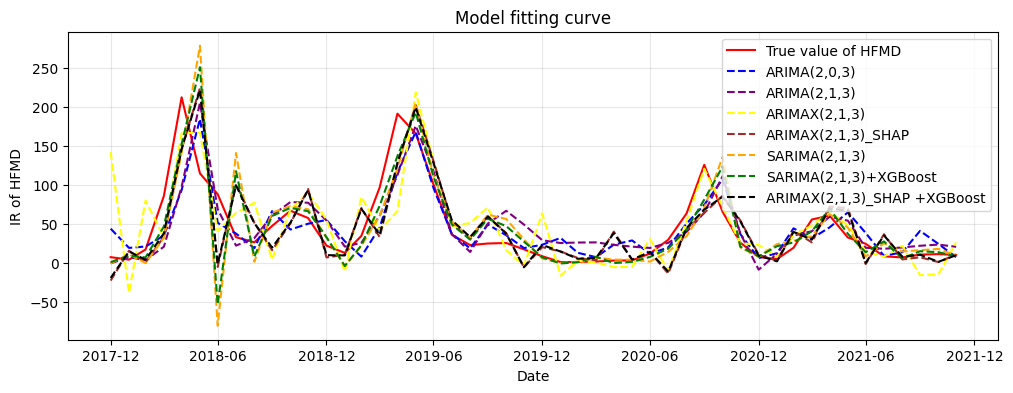

In [90]:
#可视化模型预测结果_训练集
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.plot(df_train.index, df_train['IR'], label='True value of HFMD', color='red',linestyle='-')
plt.plot(df_train.index, train_pred1, label='ARIMA(2,0,3)', color='blue',linestyle='--')
plt.plot(df_train.index, train_pred2, label='ARIMA(2,1,3)', color='purple',linestyle='--')
plt.plot(df_train.index, train_predX, label='ARIMAX(2,1,3)', color='yellow',linestyle='--')
plt.plot(df_train.index, train_predSHAPX, label='ARIMAX(2,1,3)_SHAP', color='brown',linestyle='--')
plt.plot(df_train.index, df_train['sarima_fit'], label='SARIMA(2,1,3)', color='orange', linestyle='--')
plt.plot(df_train.index, df_train['hybrid_fit'], label='SARIMA(2,1,3)+XGBoost', color='green', linestyle='--')
plt.plot(df_train.index, dftrain_arimax['hybrid_fit'], label='ARIMAX(2,1,3)_SHAP +XGBoost', color='black',linestyle='--')
plt.title('Model fitting curve')
plt.xlabel('Date')
plt.ylabel('IR of HFMD')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

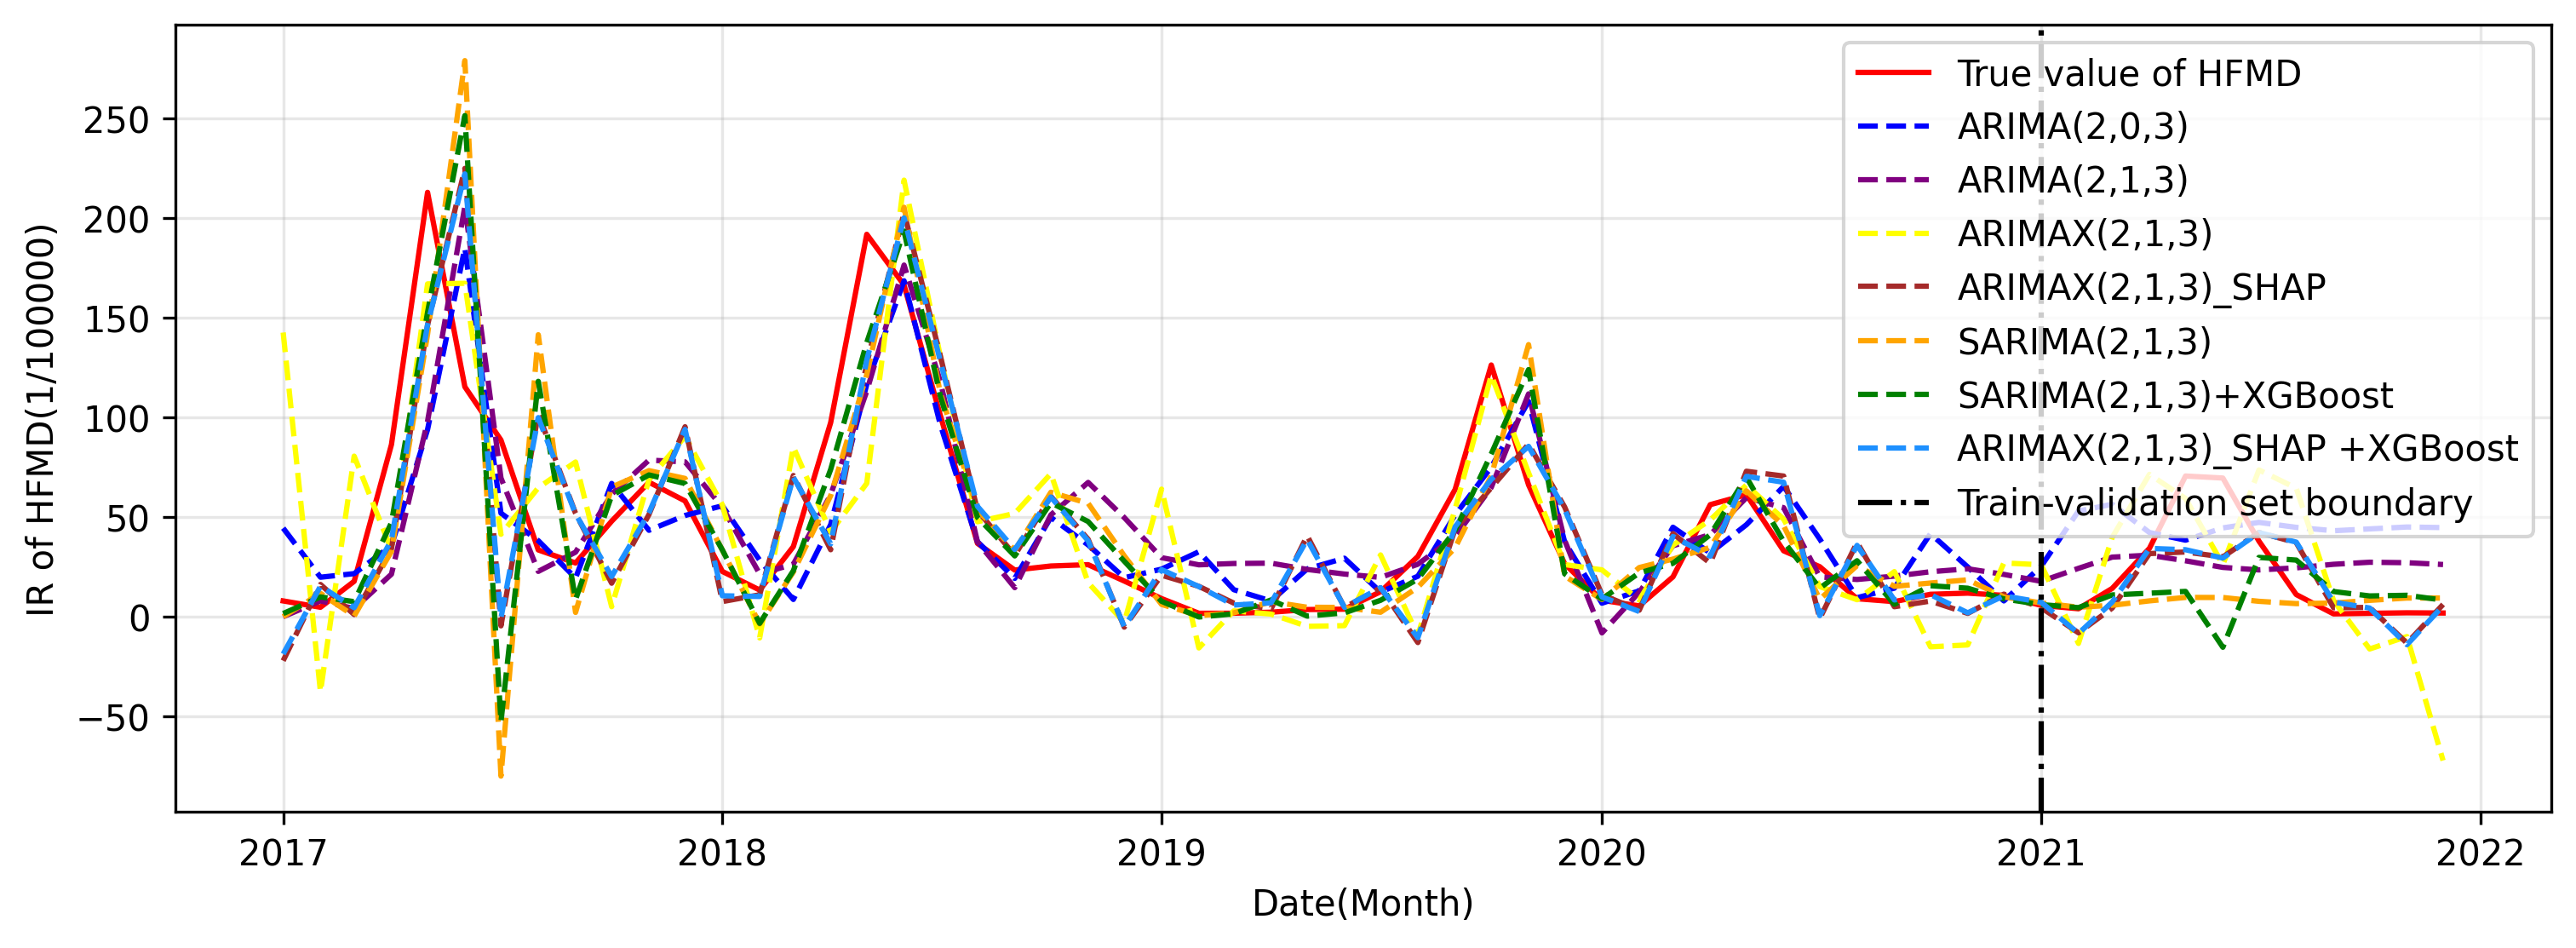

In [91]:
#可视化模型预测结果_训练集
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4),dpi=300)
plt.plot(pd.concat([df_train,df_test],axis=0).index, pd.concat([df_train['IR'],df_test['IR']],axis=0), label='True value of HFMD', color='red',linestyle='-')
plt.plot(pd.concat([df_train,df_test],axis=0).index, pd.concat([train_pred1,test_pred1],axis=0), label='ARIMA(2,0,3)', color='blue',linestyle='--')
plt.plot(pd.concat([df_train,df_test],axis=0).index, pd.concat([train_pred2,test_pred2],axis=0), label='ARIMA(2,1,3)', color='purple',linestyle='--')
plt.plot(pd.concat([df_train,df_test],axis=0).index, pd.concat([train_predX,test_predX],axis=0), label='ARIMAX(2,1,3)', color='yellow',linestyle='--')
plt.plot(pd.concat([df_train,df_test],axis=0).index, pd.concat([train_predSHAPX,test_predSHAPX],axis=0), label='ARIMAX(2,1,3)_SHAP', color='brown',linestyle='--')
plt.plot(pd.concat([df_train,df_test],axis=0).index, pd.concat([df_train['sarima_fit'],df_test['sarima_fit']],axis=0), label='SARIMA(2,1,3)', color='orange', linestyle='--')
plt.plot(pd.concat([df_train,df_test],axis=0).index, pd.concat([df_train['hybrid_fit'],df_test['hybrid_pred']],axis=0), label='SARIMA(2,1,3)+XGBoost', color='green', linestyle='--')
plt.plot(pd.concat([df_train,df_test],axis=0).index, pd.concat([dftrain_arimax['hybrid_fit'],dftest_arimax['hybrid_pred']],axis=0), label='ARIMAX(2,1,3)_SHAP +XGBoost', color='#1E90FF',linestyle='--')
plt.title('')
plt.axvline(x=pd.to_datetime('2022-01-01'),color='black', linestyle='-.',label='Train-validation set boundary')
plt.xlabel('Date(Month)')
plt.ylabel('IR of HFMD(1/100000)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

预测因子分析

**双模型 SHAP 融合分析**

量化每个气象因子对最终预测结果的总贡献、影响方向、重要性排序

ARIMAX 模块：计算线性 SHAP 值得到气象因子对主预测值的贡献；

XGBoost 模块：计算树模型 SHAP 值，得到气象因子对残差修正的贡献；

总贡献融合：单个气象因子总 SHAP 值 = ARIMAX 贡献 + XGBoost 贡献；

In [92]:
# ARIMAX 输入气象变量
ARIMAX_METEO = ['temperature_mean','temperature_min', 'temperature_max','petPM(mm)','precipitation(mm)','precipitation(mm)_Log1']
# XGBoost 输入气象变量
XGB_FEATURES = ['petPM(mm)','precipitation(mm)','precipitation(mm)_Log1']

策略 1：分层特征重要性分析

适用场景：分别量化ARIMAX 线性预测和XGBoost 残差修正中，气象变量的重要性排序。

具体操作：

ARIMAX 模块：用模型回归系数、t 检验值、方差解释率，判断：
温度三因子、降水、蒸散对 HFMD 的线性时序贡献；
系数正负 = 影响方向，绝对值 = 影响强度。

XGBoost 模块：输出模型内置 3 种重要性：
gain（最推荐）：气象变量对残差预测的总贡献占比；
weight：变量使用次数；cover：覆盖样本量。

核心结论输出
哪些气象变量主导线性预测（ARIMAX）？
哪些气象变量主导非线性残差修正（XGBoost）？

In [102]:
# 提取ARIMAX外生变量（气象因子）的回归结果
# 结果中：前n个为外生变量系数，后面为AR/MA项
n_exog = len(ARIMAX_METEO)
coef = ARIMAX_SHAP.params[:n_exog]          # 回归系数
pvalues =ARIMAX_SHAP.pvalues[:n_exog]      # p值
tvalues =ARIMAX_SHAP.tvalues[:n_exog]      # t统计量

/root/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


In [103]:
# 计算ARIMAX特征重要性（3种指标）
arimax_importance = pd.DataFrame({
    '气象变量': ARIMAX_METEO,
    '回归系数': coef.round(4),
    't统计量绝对值': np.abs(tvalues).round(4),
    'p值': pvalues.round(6),
    '重要性(系数绝对值)': np.abs(coef).round(4)  # 核心重要性指标
})

In [104]:
arimax_importance

,气象变量,回归系数,t统计量绝对值,p值,重要性(系数绝对值)
temperature_mean,temperature_mean,2094.9747,inf,0.0,2094.9747
temperature_min,temperature_min,-1022.3044,inf,0.0,1022.3044
temperature_max,temperature_max,-1156.8052,5.823803e+36,0.0,1156.8052
petPM(mm),petPM(mm),65.3222,3.273462e+35,0.0,65.3222
precipitation(mm),precipitation(mm),28.3995,5.309585e+34,0.0,28.3995
precipitation(mm)_Log1,precipitation(mm)_Log1,22.4363,1.035224e+35,0.0,22.4363


In [105]:
arimax_importance.to_csv('/root/ToResult/AutoTS/ARIMAX_Importance.csv')

In [106]:
# 提取XGBoost特征重要性（gain=总贡献占比）
xgb_importance = pd.DataFrame({
    '气象变量': XGB_FEATURES,
    '重要性(Gain)':best_model_xgb_arimax.feature_importances_.round(4)  # 最核心指标
})
xgb_importance =xgb_importance.sort_values('重要性(Gain)', ascending=False)

In [107]:
xgb_importance

,气象变量,重要性(Gain)
1,precipitation(mm),0.4458
2,precipitation(mm)_Log1,0.3823
0,petPM(mm),0.1719


In [108]:
xgb_importance.to_csv('/root/ToResult/AutoTS/XGBoost_Importance.csv')

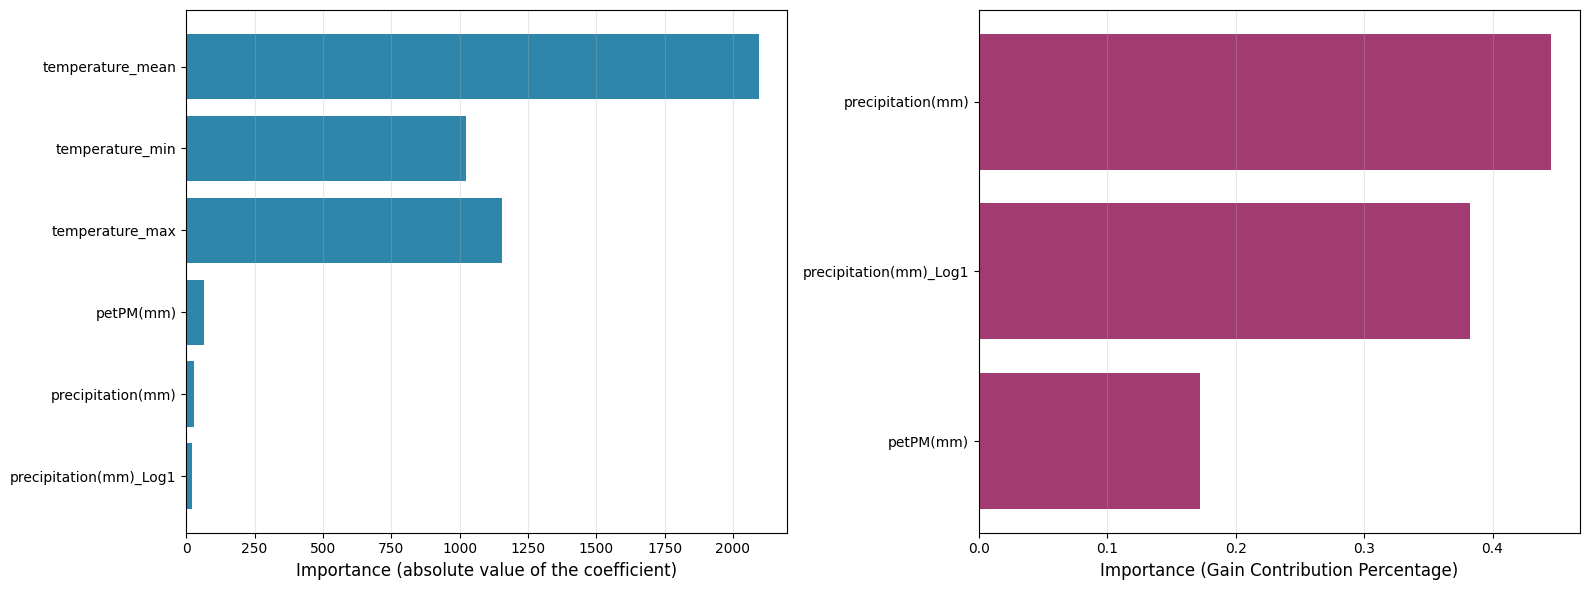

In [109]:
#分层重要性可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
#子图1：ARIMAX 气象变量重要性
ax1.barh(arimax_importance['气象变量'][::-1], arimax_importance['重要性(系数绝对值)'][::-1], color='#2E86AB')
ax1.set_xlabel('Importance (absolute value of the coefficient)', fontsize=12)
ax1.set_title('', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
# 子图2：XGBoost 气象变量重要性
ax2.barh(xgb_importance['气象变量'][::-1], xgb_importance['重要性(Gain)'][::-1], color='#A23B72')
ax2.set_xlabel('Importance (Gain Contribution Percentage)', fontsize=12)
ax2.set_title('', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()